# Figure 6: Growth Rate Performance Zoom-Ins

## Package Imports

In [8]:
# General imports
import glob
import json
import random
import sys
from typing import Optional, List, Dict, Any

# Data handling and visualization
import pandas as pd
import numpy as np
import evofr as ef
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import seaborn as sns

from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    get_filtered_growth_rates_df,
    filter_growth_rates
)

from antigentools.plot import (
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_cases, 
    get_analysis_window, # Move this to utils.py?
    print_window_stats, # Move this to utils.py?
)

# Publication styling imports
from antigentools.publication_style import (
    apply_publication_styling_to_figure,
    style_figure_for_publication,
    PublicationFigureStyler,
    publication_style
)

# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
MIN_VARIANT_INCIDENCE = 50.0  # Minimum smoothed variant incidence to consider
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics
build = "flu-simulated-150k-samples-final"
print(f"Analysis configuration for build: {build}:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  MIN_VARIANT_INCIDENCE: {MIN_VARIANT_INCIDENCE}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")

Analysis configuration for build: flu-simulated-150k-samples-final:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  MIN_VARIANT_INCIDENCE: 50.0
  EPSILON (overestimation tolerance): 0.001


In [2]:
# Plotting configuration 
# Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

# Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

# Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

# Variant color map
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#4c72b0'), (1, '#dd8452'), (2, '#55a868'), (3, '#c44e52'), (4, '#8172b3')]


In [3]:
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")

In [4]:
# Helper functions adapted from manuscript-figure-3.ipynb for plotting inferred growth rates

def plot_observed_cases_clean(ax, evo_dict, location, pivot_idx=None, label_fontsize=14):
    """Plot observed cases histogram - clean version without legend."""
    t = np.arange(0, evo_dict[location].cases.shape[0])
    
    # Only plot data up to pivot if specified
    if pivot_idx:
        pivot_t = pivot_idx[0]
        # Filter cases to training window
        t_train = t[t <= pivot_t]
        cases_train = evo_dict[location].cases[t <= pivot_t]
    else:
        t_train = t
        cases_train = evo_dict[location].cases
    
    ax.bar(t_train, cases_train, width=5.0, color='black', alpha=0.5)
    
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    ax.set_ylabel("Cases", fontsize=label_fontsize, fontweight='normal')


def plot_frequencies_nowcast_only(
    ax: plt.Axes, 
    ef_data: Dict[str, Any], 
    freqs: pd.DataFrame, 
    deme: str, 
    model: str, 
    color_map: Dict[str, str], 
    p: int = 50, 
    pivot_idx: Optional[List[int]] = None,
    label_fontsize: int = 14
) -> None:
    """Plot observed and nowcast frequencies of variants (training window only) - no legend."""
    # Get variant names
    v_names = sorted(ef_data[deme].var_names)
    n_variant = len(v_names)
    
    # Calculate observed frequencies
    obs_freq = np.divide(ef_data[deme].seq_counts, ef_data[deme].seq_counts.sum(axis=1)[:, None])
    t = np.arange(0, obs_freq.shape[0])

    # Grab predicted frequencies of interest
    deme_freq = freqs.query(f'location == "{deme}" and model == "{model}"')
    
    for variant in range(n_variant):
        v_name = v_names[variant]
        variant_df = deme_freq.query(f'variant == {v_name}')
        
        # Only plot data up to pivot index
        if pivot_idx:
            pivot_t = pivot_idx[0]
            # Filter observed frequencies to training window
            train_mask = t <= pivot_t
            t_train = t[train_mask]
            obs_freq_train = obs_freq[train_mask, variant]
            
            # Filter nowcast data to training window
            variant_df_train = variant_df[variant_df['t'] <= pivot_t]
        else:
            t_train = t
            obs_freq_train = obs_freq[:, variant]
            variant_df_train = variant_df
        
        # Plot observed frequencies (no label to avoid legend)
        ax.scatter(t_train, obs_freq_train, color=color_map[v_name], 
                  alpha=0.9, s=80, edgecolors='black', linewidth=0.5, zorder=5)
        
        # Plot nowcasts (no label to avoid legend)
        if not variant_df_train.empty:
            ax.plot(variant_df_train['t'], variant_df_train['median_freq_nowcast'], 
                   lw=2.5, color=color_map[v_name], zorder=4)
            ax.fill_between(variant_df_train['t'], 
                          variant_df_train[f'freq_lower_{p}'], 
                          variant_df_train[f'freq_upper_{p}'], 
                          color=color_map[v_names[variant]], alpha=0.2, zorder=1)
    
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    ax.set_ylabel("Frequency", fontsize=label_fontsize, fontweight='normal')
    ax.set_ylim(0, 1.05)


def plot_variant_incidence(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=14):
    """Plot variant incidence calculated from growth rates data - no legend."""
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No incidence data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Variant Incidence', fontsize=label_fontsize, fontweight='normal')
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot incidence for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty or 'variant_incidence_smoothed' not in variant_data.columns:
            continue
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Map week_start dates to t values using the evofr date mapping
        t_values = []
        incidence_values = []
        
        for idx, row in variant_data.iterrows():
            week_date = row['week_start_norm']
            # Find the closest date in our evofr date mapping
            if week_date in date_to_t:
                t_val = date_to_t[week_date]
            else:
                # Find closest date if exact match not found
                date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                if date_diffs:
                    min_diff, closest_date = min(date_diffs)
                    if min_diff <= 7:  # Only include if within a week
                        t_val = date_to_t[closest_date]
                    else:
                        continue
                else:
                    continue
            
            # Only include data up to pivot if specified
            if pivot_idx and t_val > pivot_idx[0]:
                continue
                
            t_values.append(t_val)
            incidence_values.append(row['variant_incidence_smoothed'])
        
        if not t_values:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Plot as line (no label to avoid legend)
        ax.scatter(t_values, incidence_values, 
                alpha=0.9, s=80, color=variant_color,
                          edgecolors='black', linewidth=0.5, zorder=5)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    # Set labels and formatting
    ax.set_ylabel('Variant Incidence', fontsize=label_fontsize, fontweight='normal')


def plot_r_data_vs_r_model_clean(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=14, p=95):
    """Plot r_data (observed) vs r_model (inferred) growth rates with confidence intervals - no legend."""
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No growth rate data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Growth Rate', fontsize=label_fontsize, fontweight='normal')
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot growth rates for each variant (no legends)
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Apply filtering logic
        valid_r_data = variant_data[~variant_data['growth_rate_r_data'].isna()].copy()
        
        if 'MIN_SEGMENT_LENGTH' in globals() and MIN_SEGMENT_LENGTH is not None:
            # Create a temporary DataFrame for filtering
            temp_df = variant_data.copy()
            temp_df['country'] = location
            temp_df['variant'] = variant
            temp_df['date'] = temp_df['week_start_norm']
            
            # Use the filter_growth_rates function if available
            if 'filter_growth_rates' in globals():
                filtered_variant_data = filter_growth_rates(
                    temp_df, 
                    r_data_col='growth_rate_r_data', 
                    connect_gaps=globals().get('CONNECT_GAPS', True), 
                    min_segment_length=MIN_SEGMENT_LENGTH
                )
                valid_r_data = filtered_variant_data[~filtered_variant_data['growth_rate_r_data'].isna()].copy()
        
        # Create a mapping of dates to observed data status
        observed_dates = set()
        
        # Map dates to t values and plot r_data
        if not valid_r_data.empty:
            t_values_r_data = []
            r_data_values = []
            
            for idx, row in valid_r_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:
                            t_value = date_to_t[closest_date]
                
                # Only include data up to pivot
                if t_value is not None and pd.notna(row['growth_rate_r_data']):
                    if pivot_idx and t_value > pivot_idx[0]:
                        continue
                    t_values_r_data.append(t_value)
                    r_data_values.append(row['growth_rate_r_data'])
                    observed_dates.add(week_date)  # Track observed dates
            
            # Plot observed growth rates as scatter points (no label)
            if t_values_r_data:
                ax.scatter(t_values_r_data, r_data_values, 
                          color=variant_color, alpha=0.9, s=80, 
                          edgecolors='black', linewidth=0.5, zorder=5)
        
        # For median_r, only plot at dates where we have observations
        if not variant_data.empty and not variant_data['median_r'].isna().all():
            # Filter to rows that have median_r and observed data
            model_data = variant_data[
                (~variant_data['median_r'].isna()) & 
                (variant_data['week_start_norm'].isin(observed_dates))
            ].copy()
            
            if not model_data.empty:
                # Check if confidence interval columns exist
                r_lower_col = f'r_lower_{p}'
                r_upper_col = f'r_upper_{p}'
                has_confidence_intervals = (r_lower_col in model_data.columns) and (r_upper_col in model_data.columns)
                
                t_values_r_model = []
                r_model_values = []
                r_lower_values = []
                r_upper_values = []
                
                for idx, row in model_data.iterrows():
                    week_date = row['week_start_norm']
                    t_value = None
                    
                    if week_date in date_to_t:
                        t_value = date_to_t[week_date]
                    else:
                        # Find closest date
                        date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                        if date_diffs:
                            min_diff, closest_date = min(date_diffs)
                            if min_diff <= 7:
                                t_value = date_to_t[closest_date]
                    
                    # Only include data up to pivot
                    if t_value is not None:
                        if pivot_idx and t_value > pivot_idx[0]:
                            continue
                        t_values_r_model.append(t_value)
                        r_model_values.append(row['median_r'])
                        if has_confidence_intervals:
                            r_lower_values.append(row[r_lower_col])
                            r_upper_values.append(row[r_upper_col])
                
                # Plot inferred growth rates as lines with confidence intervals - with gap detection
                if t_values_r_model:
                    # Sort by time
                    if has_confidence_intervals:
                        sorted_data = sorted(zip(t_values_r_model, r_model_values, r_lower_values, r_upper_values))
                        sorted_t, sorted_r, sorted_lower, sorted_upper = zip(*sorted_data) if sorted_data else ([], [], [], [])
                    else:
                        sorted_data = sorted(zip(t_values_r_model, r_model_values))
                        sorted_t, sorted_r = zip(*sorted_data) if sorted_data else ([], [])
                    
                    # Break into segments where gaps > threshold
                    segments = []
                    current_t = [sorted_t[0]]
                    current_r = [sorted_r[0]]
                    if has_confidence_intervals:
                        current_lower = [sorted_lower[0]]
                        current_upper = [sorted_upper[0]]
                    
                    for i in range(1, len(sorted_t)):
                        # If gap is <= 14 days (time units), continue segment
                        if sorted_t[i] - sorted_t[i-1] <= 14:
                            current_t.append(sorted_t[i])
                            current_r.append(sorted_r[i])
                            if has_confidence_intervals:
                                current_lower.append(sorted_lower[i])
                                current_upper.append(sorted_upper[i])
                        else:
                            # Gap detected, save segment and start new one
                            if len(current_t) >= 2:  # Only plot segments with at least 2 points
                                if has_confidence_intervals:
                                    segments.append((current_t, current_r, current_lower, current_upper))
                                else:
                                    segments.append((current_t, current_r))
                            current_t = [sorted_t[i]]
                            current_r = [sorted_r[i]]
                            if has_confidence_intervals:
                                current_lower = [sorted_lower[i]]
                                current_upper = [sorted_upper[i]]
                    
                    # Add final segment
                    if len(current_t) >= 2:
                        if has_confidence_intervals:
                            segments.append((current_t, current_r, current_lower, current_upper))
                        else:
                            segments.append((current_t, current_r))
                    
                    # Plot each segment with confidence bands
                    if has_confidence_intervals:
                        for seg_t, seg_r, seg_lower, seg_upper in segments:
                            # Plot confidence band first (behind line)
                            ax.fill_between(seg_t, seg_lower, seg_upper, 
                                          color=variant_color, alpha=0.2, zorder=1)
                            # Plot median line
                            ax.plot(seg_t, seg_r, 
                                   color=variant_color, linewidth=2.5, alpha=0.9, zorder=4)
                    else:
                        # Just plot lines without confidence bands
                        for segment in segments:
                            seg_t, seg_r = segment[0], segment[1]
                            ax.plot(seg_t, seg_r, 
                                   color=variant_color, linewidth=2.5, alpha=0.9, zorder=4)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    # Set labels and formatting
    ax.set_ylabel('Growth Rate (per day)', fontsize=label_fontsize, fontweight='normal')
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1, zorder=1)


def plot_inferred_growth_rates(
    pivot_date: str, 
    location: str, 
    model: str, 
    build: str, 
    growth_rates_df: pd.DataFrame, 
    color_map: dict, 
    fig_width: int = 10,
    fig_height: int = 10,
    label_fontsize: int = 14,
    title_fontsize: int = 16,
    tick_fontsize: int = 12,
    return_fig_axes: bool = False,
    p: int = 95
) -> Optional[tuple]:
    """
    Plot inferred growth rates with observed cases histogram (4-panel version).
    
    Creates a clean four-panel plot showing:
    1. Observed cases (histogram)
    2. Variant frequencies (nowcast only)
    3. Variant incidence
    4. r_data vs r_model comparison
    
    This function focuses purely on data visualization with NO individual panel legends.
    Only creates a single figure-level legend. Use publication styling functions for 
    formatting, panel labels, titles, etc.
    
    Parameters:
    -----------
    pivot_date : str
        Pivot date for analysis window
    location : str
        Location of interest
    model : str
        Model name
    build : str
        Build name
    growth_rates_df : pd.DataFrame
        DataFrame containing growth rates data
    color_map : dict
        Dictionary mapping variant names to colors
    fig_width : int, default=10
        Figure width in inches
    fig_height : int, default=10
        Figure height in inches (increased for 4 panels)
    label_fontsize : int, default=14
        Font size for axis labels
    title_fontsize : int, default=16
        Font size for figure title
    tick_fontsize : int, default=12
        Font size for tick labels
    return_fig_axes : bool, default=False
        If True, returns (fig, axes) tuple instead of showing the plot
    p : int, default=95
        Confidence level for frequency and growth rate bands (95, 80, or 50)
        
    Returns:
    --------
    Optional[tuple]
        If return_fig_axes=True, returns (fig, axes) tuple.
        Otherwise returns None and displays the plot.
    """
    # Get analysis window data
    dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
    evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(pivot_date, build, dummy_fitness_df)
    
    # Get t value for pivot date
    pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")['t'].values[0]
    
    # Filter color map to only include training variants
    current_variants = set(evo_dict[location].var_names)
    filtered_color_map = {k: v for k, v in color_map.items() if k in current_variants}
    
    # Setup figure with 4 panels (minimal styling)
    fig, axs = plt.subplots(4, 1, figsize=(fig_width, fig_height), sharex=True)
    
    # Add informative figure title
    title_text = f"{location.title()} - {model} Model - {pivot_date}"
    fig.suptitle(title_text, fontsize=title_fontsize, fontweight='bold', y=0.95)
    
    # Panel 1: Plot observed cases histogram - NO LEGEND
    plot_observed_cases_clean(
        axs[0], evo_dict, location, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
    )
    
    # Panel 2: Plot frequencies (nowcast only) with confidence intervals - NO LEGEND
    plot_frequencies_nowcast_only(
        axs[1], evo_dict, small_freqs_df, location, model, filtered_color_map, 
        p=p, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
    )
    
    # Panel 3: Plot variant incidence - NO LEGEND
    plot_variant_incidence(
        axs[2], growth_rates_df, location, filtered_color_map, evo_dict, 
        pivot_idx=[pivot_idx], label_fontsize=label_fontsize
    )
    
    # Panel 4: Plot r_data vs r_model comparison with confidence intervals - NO LEGEND
    plot_r_data_vs_r_model_clean(
        axs[3], growth_rates_df, location, filtered_color_map, evo_dict, 
        pivot_idx=[pivot_idx], label_fontsize=label_fontsize, p=p
    )
    
    # Enhanced x-axis formatting with consistent font sizing
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    tick_interval = 30
    max_t = pivot_idx
    tick_positions = list(range(0, max_t + 1, tick_interval))
    
    if len(tick_positions) > 1 and (max_t - tick_positions[-1]) < 15:
        pass
    elif tick_positions and tick_positions[-1] != max_t:
        tick_positions.append(max_t)
    
    tick_labels = []
    for i, t_pos in enumerate(tick_positions):
        if t_pos < len(dates_evofr):
            if i % 2 == 0:
                date_str = dates_evofr[t_pos].strftime('%b %Y')
            else:
                date_str = ''
            tick_labels.append(date_str)
        else:
            tick_labels.append('')
    
    axs[-1].set_xticks(tick_positions)
    axs[-1].set_xticklabels(tick_labels, rotation=0, ha='center', fontsize=tick_fontsize)
    axs[-1].set_xlabel('Date', fontsize=label_fontsize, fontweight='normal')
    
    # Apply consistent tick label sizing to all panels
    for ax in axs:
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        ax.set_xlim(-2, pivot_idx + 2)
    
    # Create ONLY ONE figure-level legend with consistent font sizing
    import matplotlib.patches as mpatches
    patches = []
    for variant, color in sorted(filtered_color_map.items()):
        patches.append(mpatches.Patch(color=color, label=f'Variant {variant}'))
    
    fig.legend(patches, [p.get_label() for p in patches], 
               loc='lower center', ncol=min(len(filtered_color_map), 5),
               bbox_to_anchor=(0.5, 0.02), fontsize=label_fontsize)
    
    # Enhanced layout adjustment to accommodate title
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, bottom=0.12)
    
    # Return figure and axes if requested
    if return_fig_axes:
        return fig, axs
    else:
        return None

## GARW Models

* Filtering on variants with log_mae > -4

### Northern deme zoom-ins

In [51]:
location = "north"
model = "GARW"

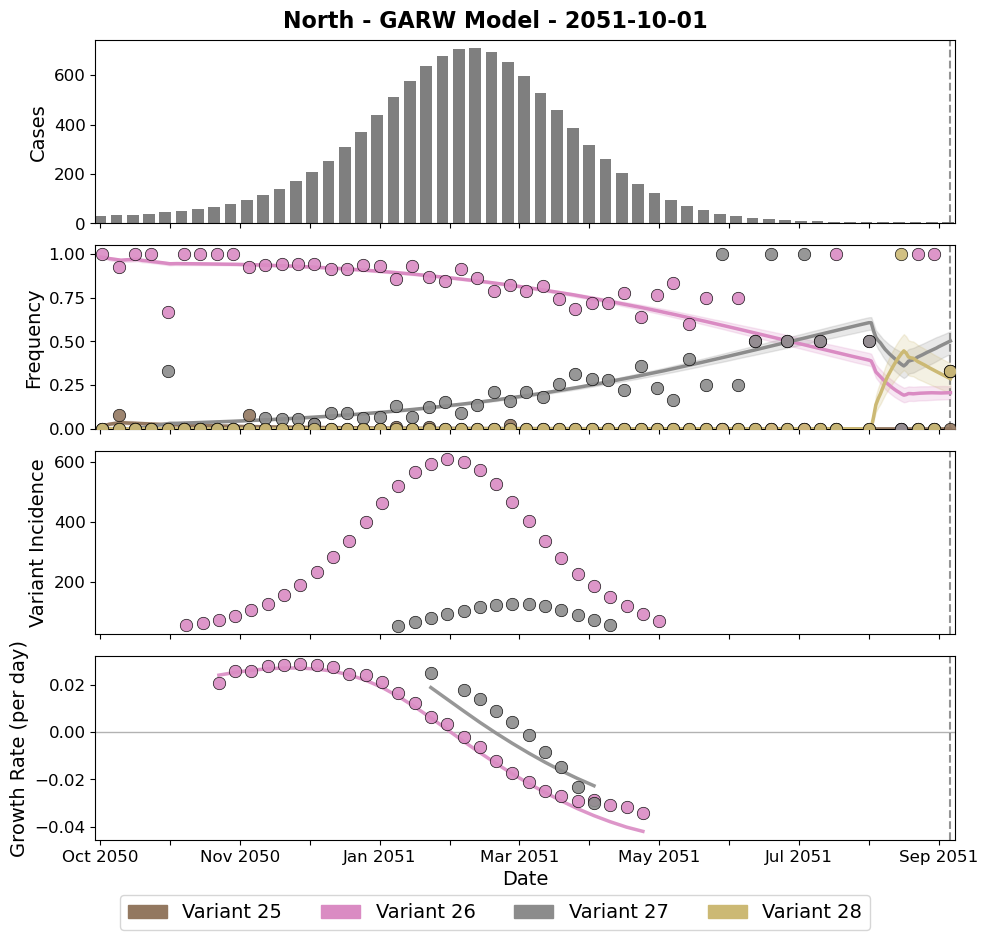

In [64]:
# A window with intermediate errors
pivot_date="2051-10-01"
growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY, min_variant_incidence=MIN_VARIANT_INCIDENCE
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

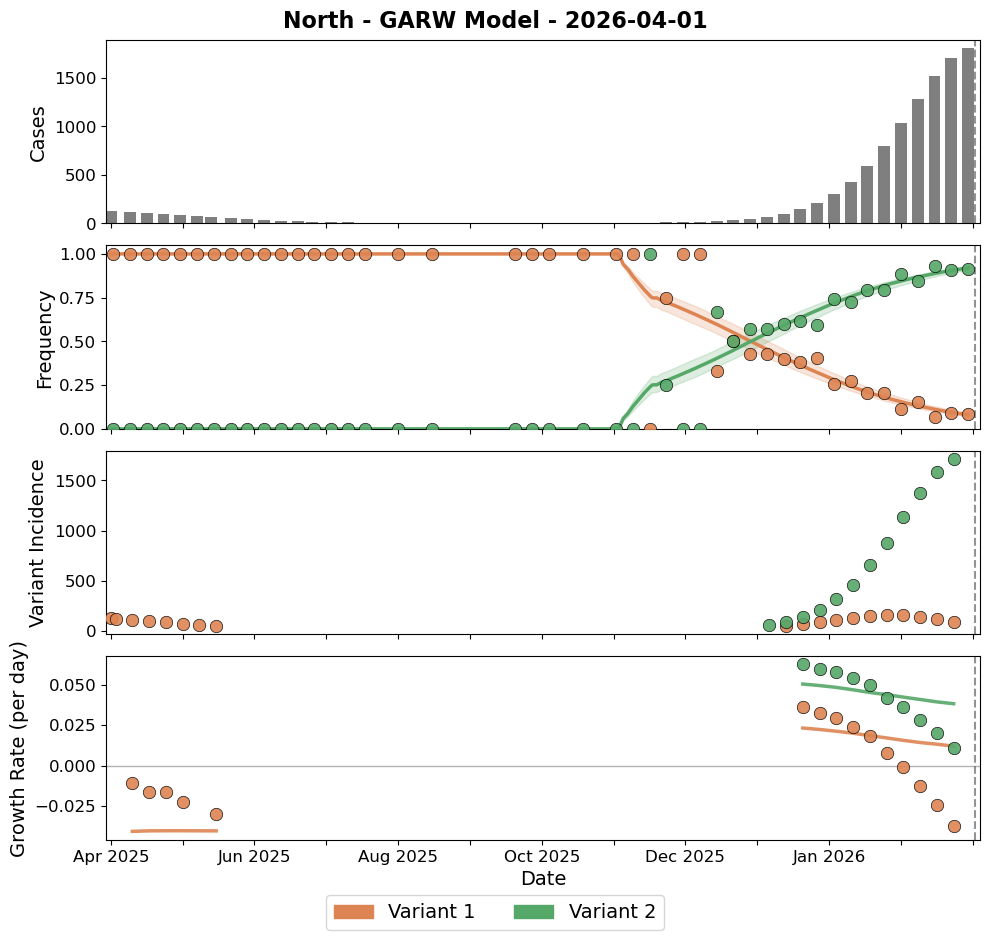

In [ ]:
# Low incidence, not interesting
pivot_date="2026-04-01"
growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY, min_variant_incidence=MIN_VARIANT_INCIDENCE
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

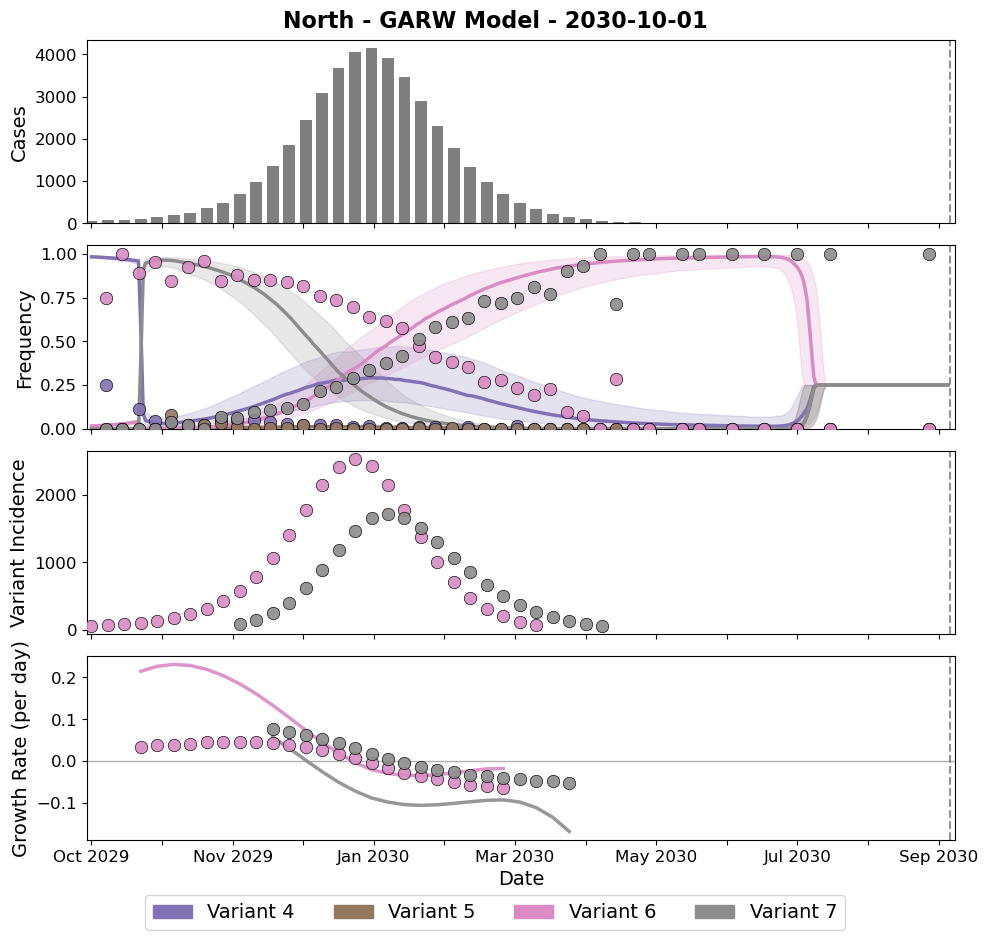

In [7]:
# This window doesn't perform well on frequency nowcasts (no convergence)
pivot_date="2030-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY, min_variant_incidence=MIN_VARIANT_INCIDENCE
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

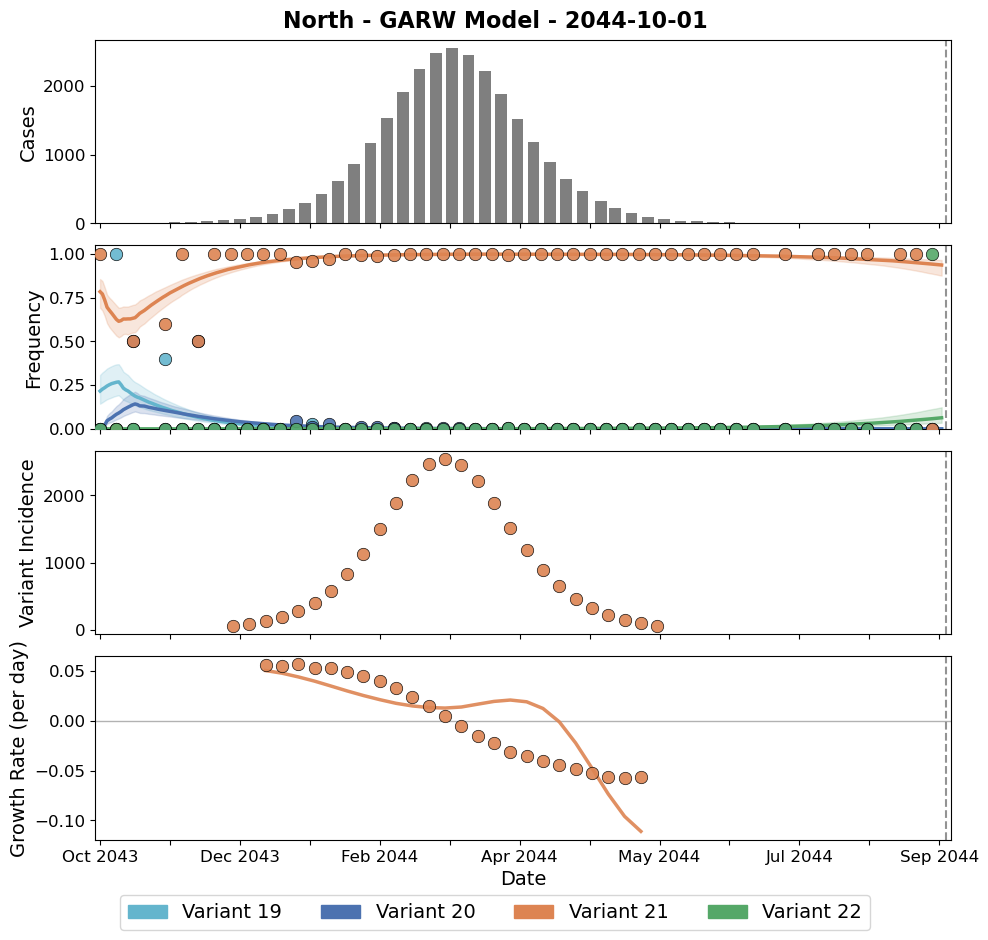

In [9]:
# Model seems to mess up here -- does the last data point for variant 22 cause this?
pivot_date="2044-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY, min_variant_incidence=MIN_VARIANT_INCIDENCE
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

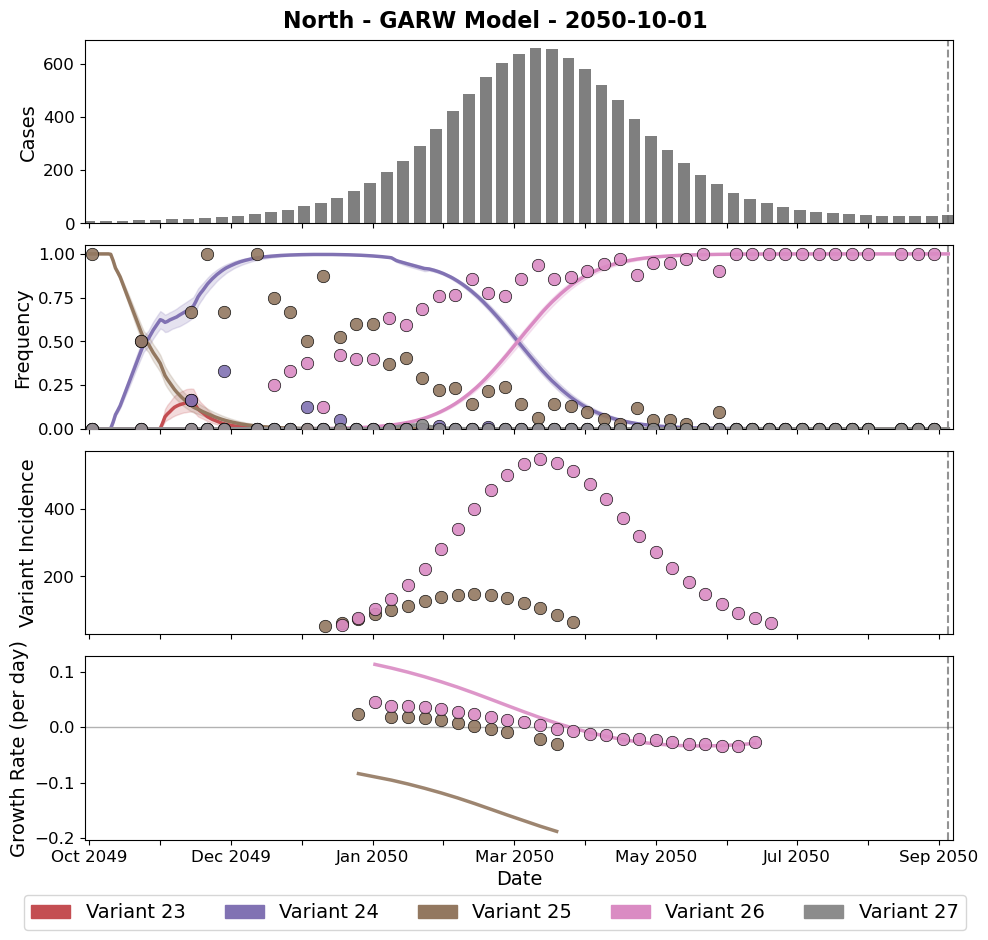

In [10]:
# Inferred frequencies aren't great here -- but model is converged.
pivot_date="2050-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY, min_variant_incidence=MIN_VARIANT_INCIDENCE
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

### Tropics deme zoom-ins

In [48]:
location = "tropics"

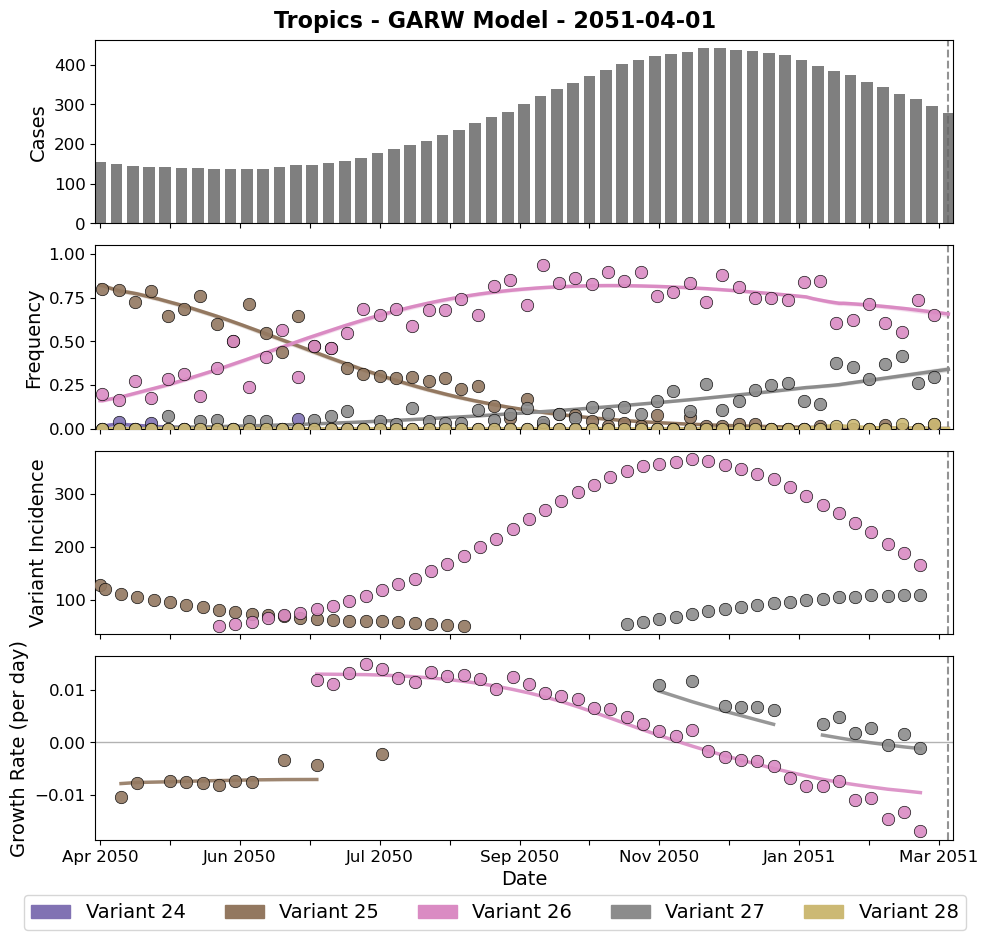

In [ ]:
# Example of good performance
pivot_date="2051-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

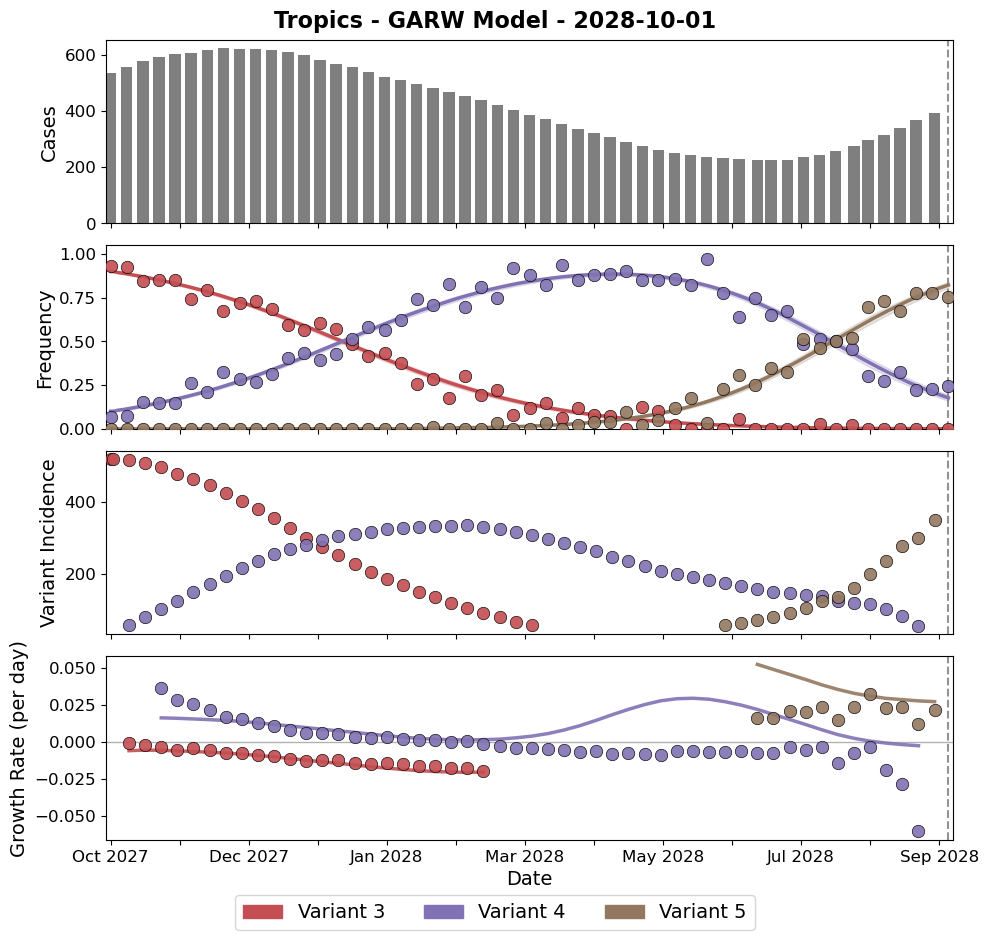

In [13]:
# Variant 5 has an incidence surge at the end of the window that is overestimated a bit
pivot_date="2028-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

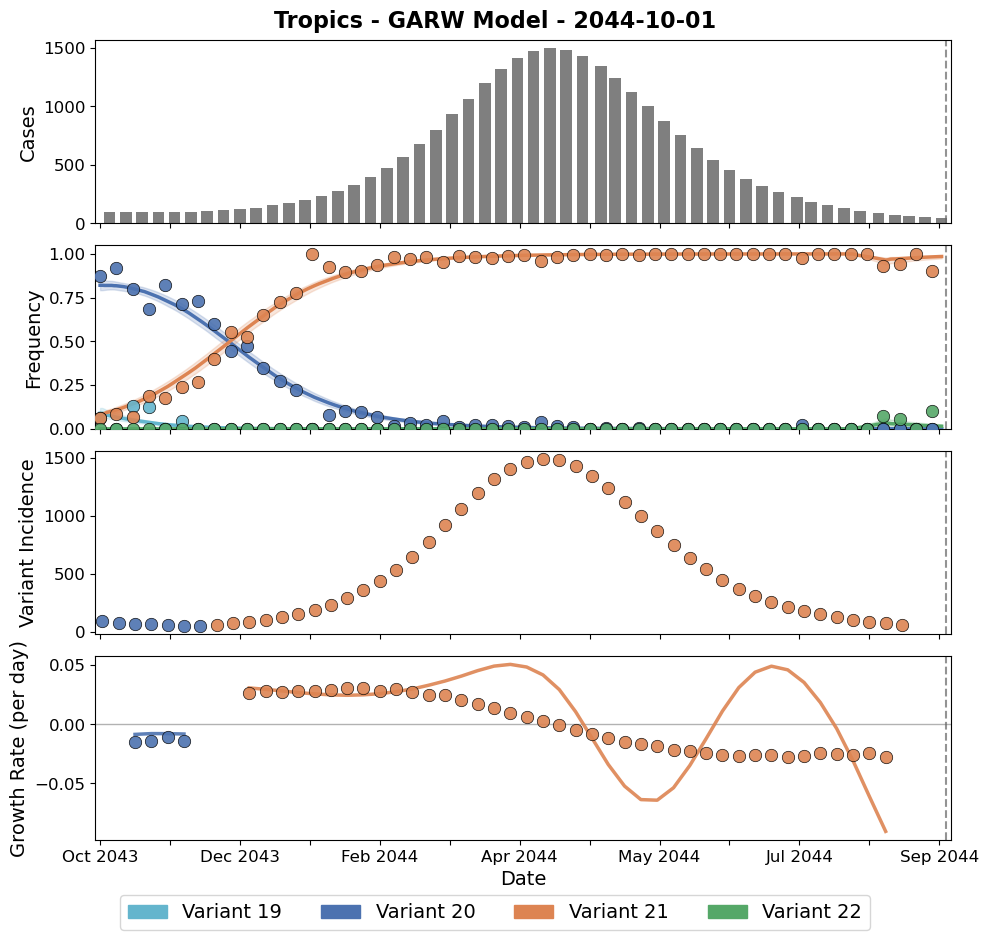

In [14]:
# WHOA! This one is really wonky!
pivot_date="2044-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

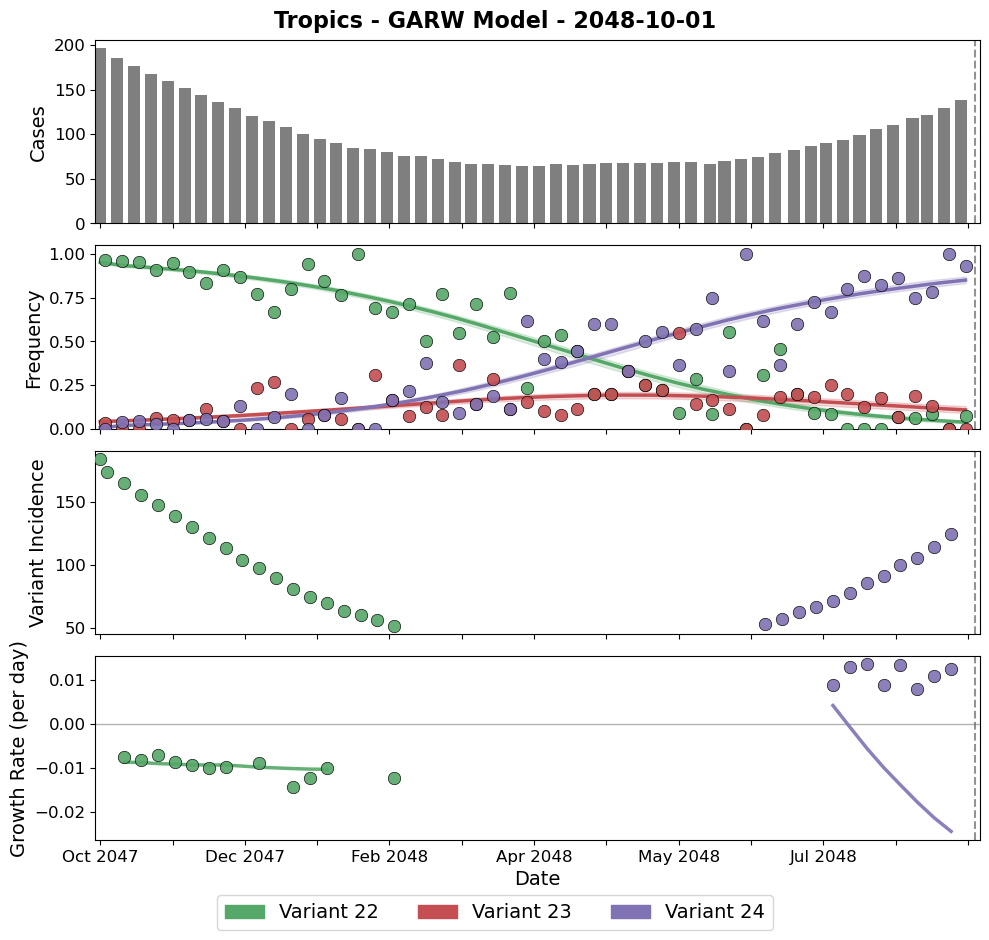

In [15]:
# Variant 24 is predicted to be decreasing as it starts its expansion -- but incidince is pretty low still
pivot_date="2048-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

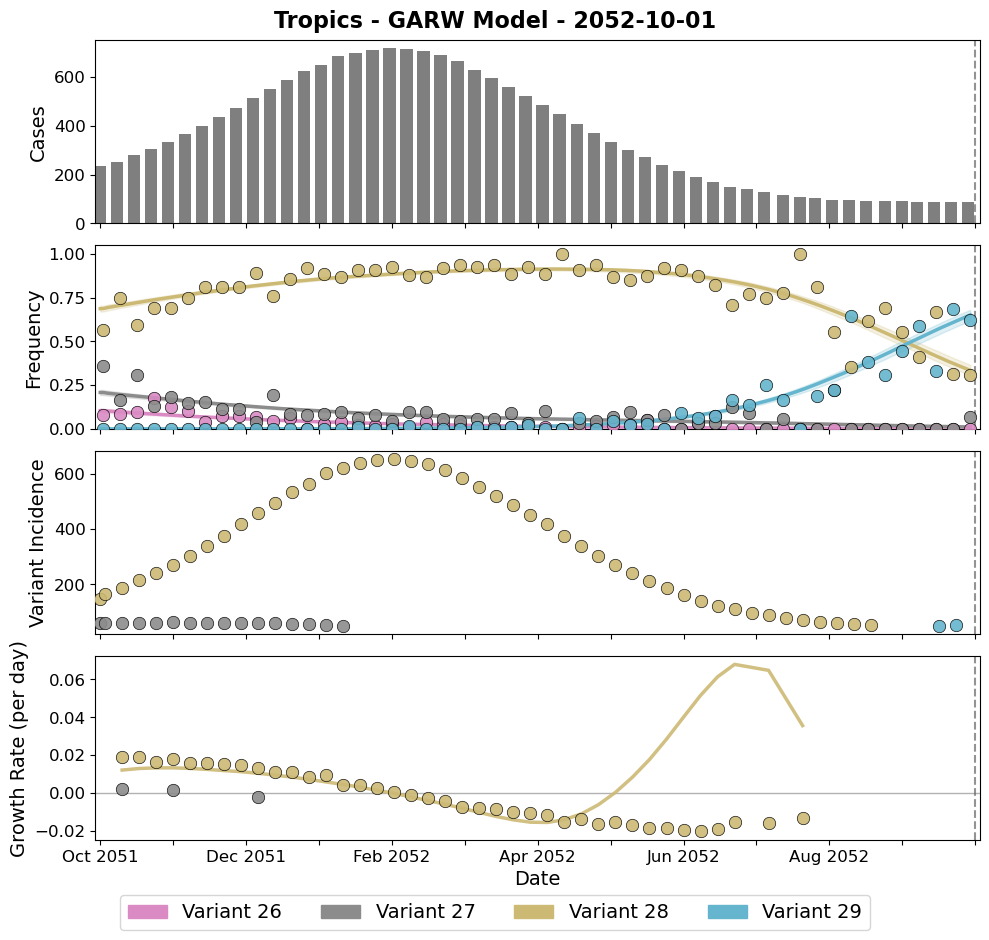

In [16]:
# Very low incidince triggers this one -- toggle filters a bit for variant 29 (start bare)
pivot_date="2052-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

### Southern deme zoom-ins

In [17]:
location = "south"

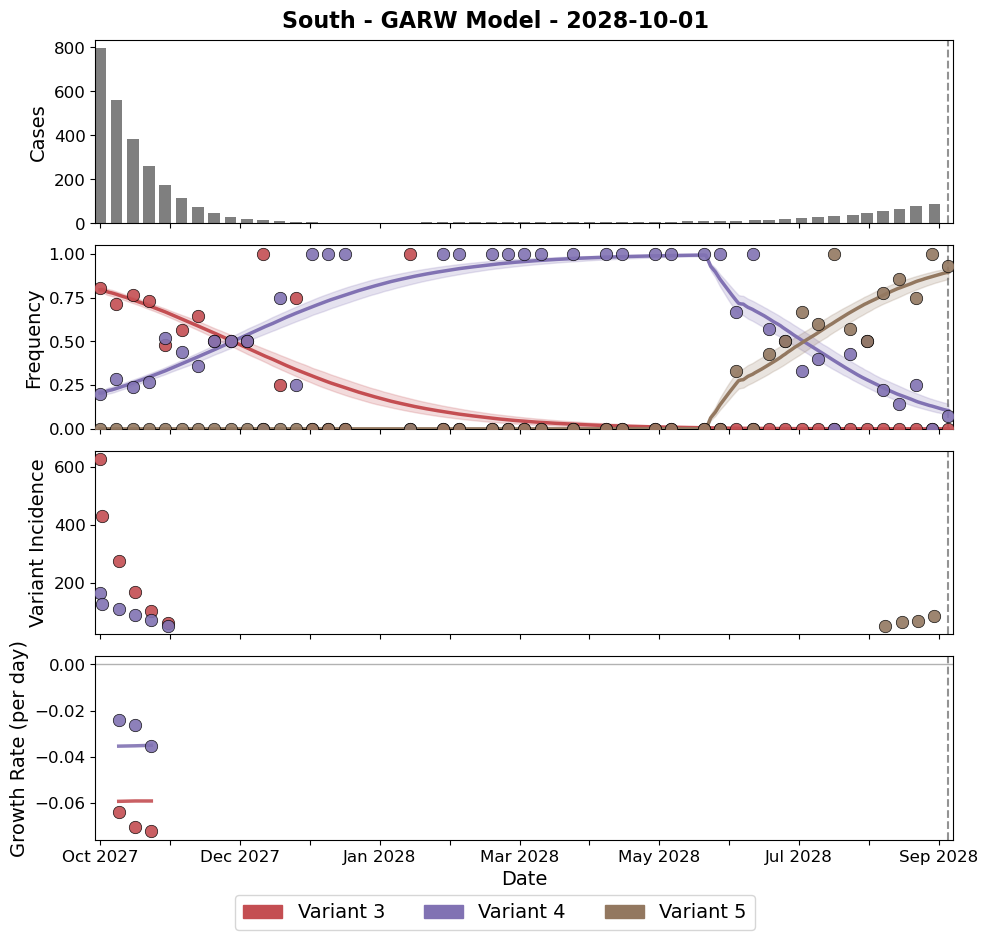

In [18]:
# Low incidence, not interesting
pivot_date="2028-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

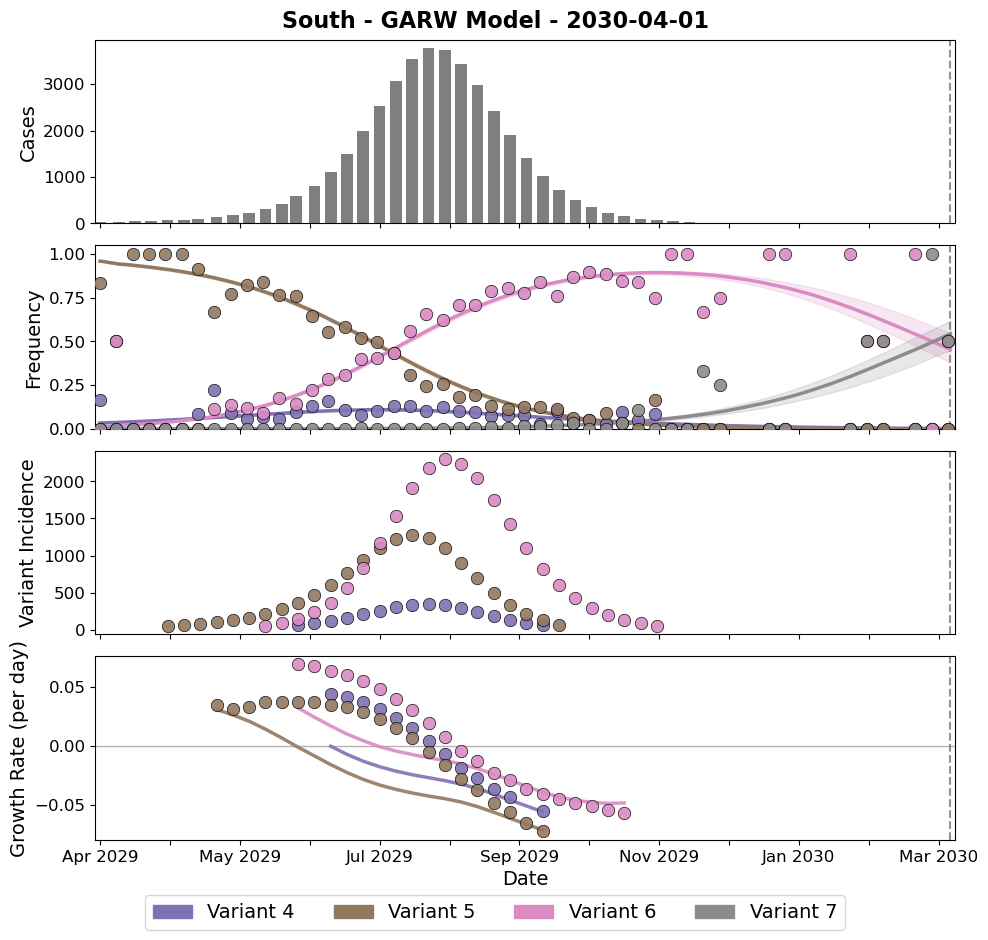

In [19]:
# Potential "king" variant (gray) drags everything down -- lets turn off the filtering with the plots later
pivot_date="2030-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

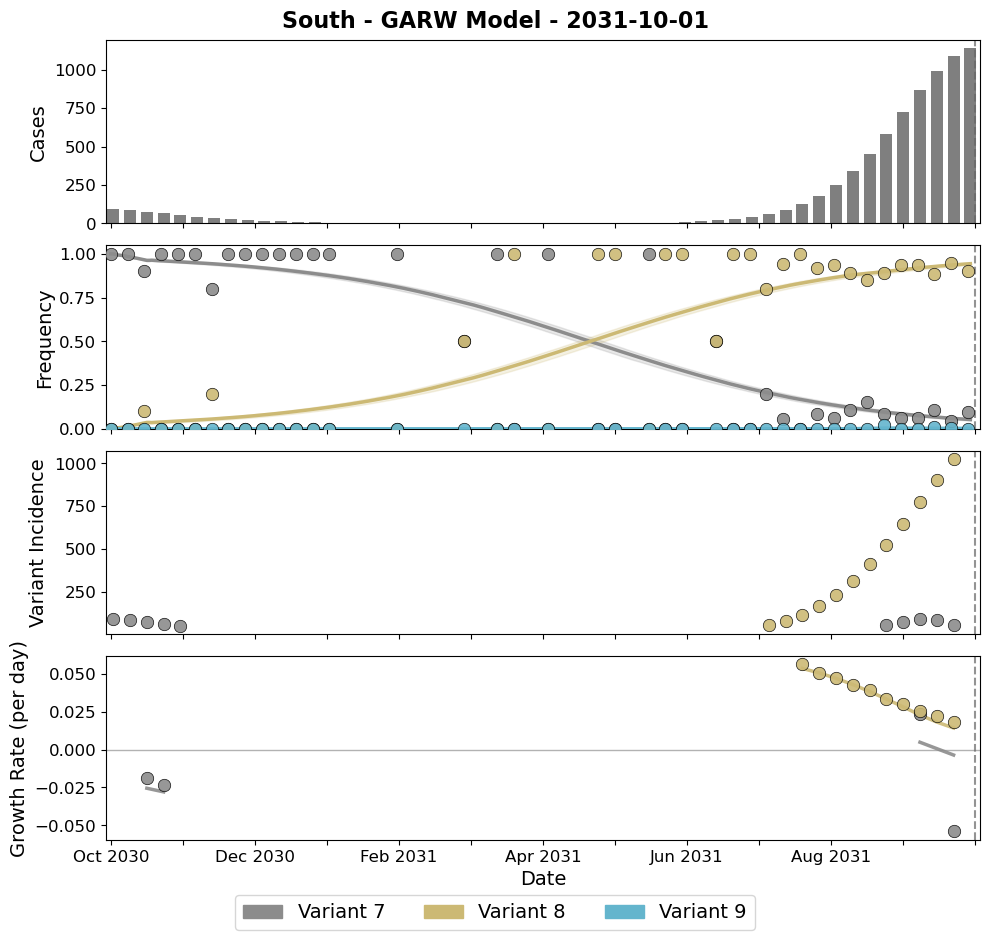

In [20]:
# Low incidence -- not interesting
pivot_date="2031-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

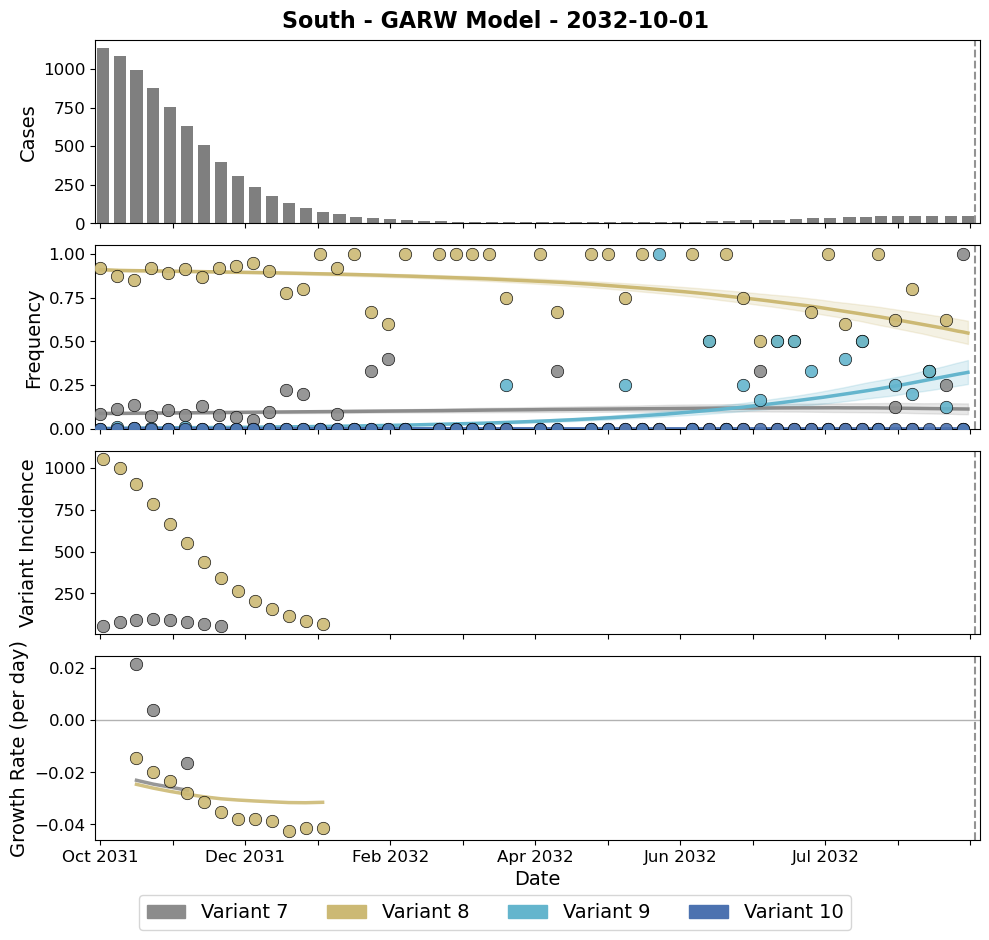

In [21]:
# Low incidence -- not interesting
pivot_date="2032-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

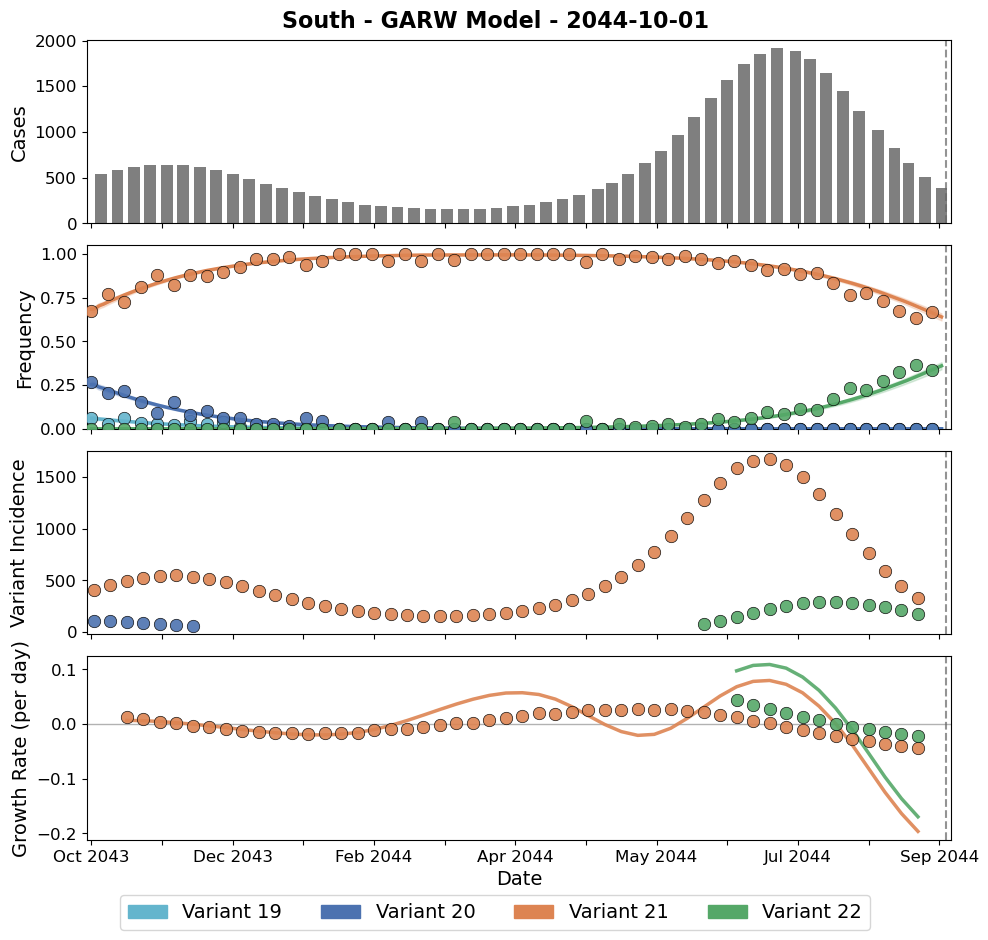

In [22]:
# This looks like another "king" variant where everything is over-estimated this time by the surge of green at the end of the window
pivot_date="2044-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

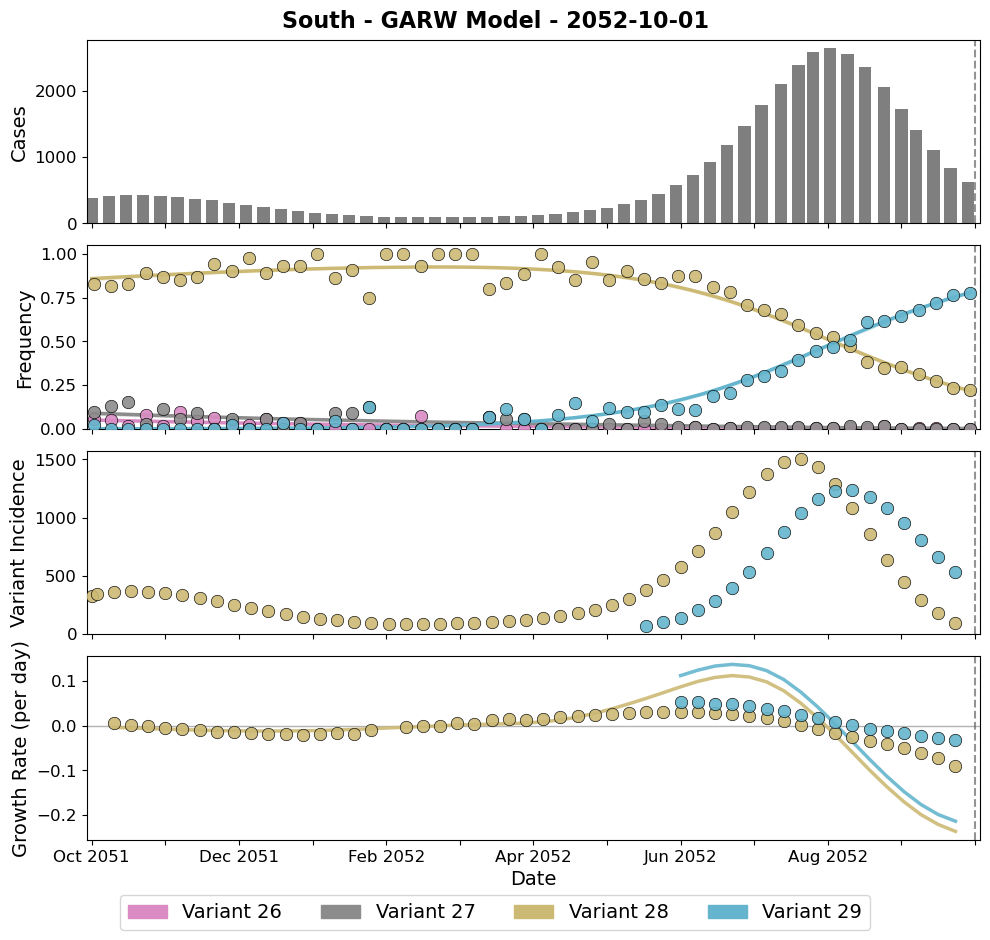

In [23]:
# This looks like another "king" variant where everything is over-estimated this time by the surge of green at the end of the window
pivot_date="2052-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

## FGA Models

In [24]:
model = "FGA"

### Northern deme zoom-ins

In [25]:
location = "north"

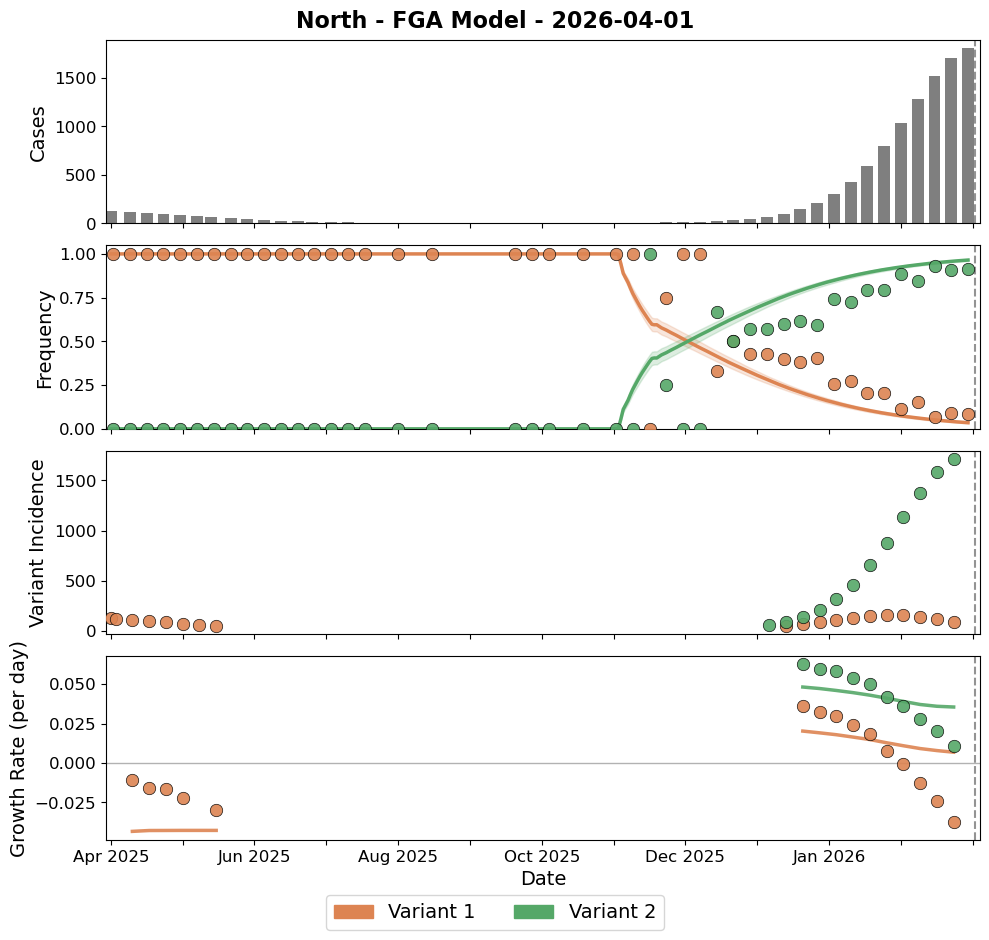

In [26]:
pivot_date="2026-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

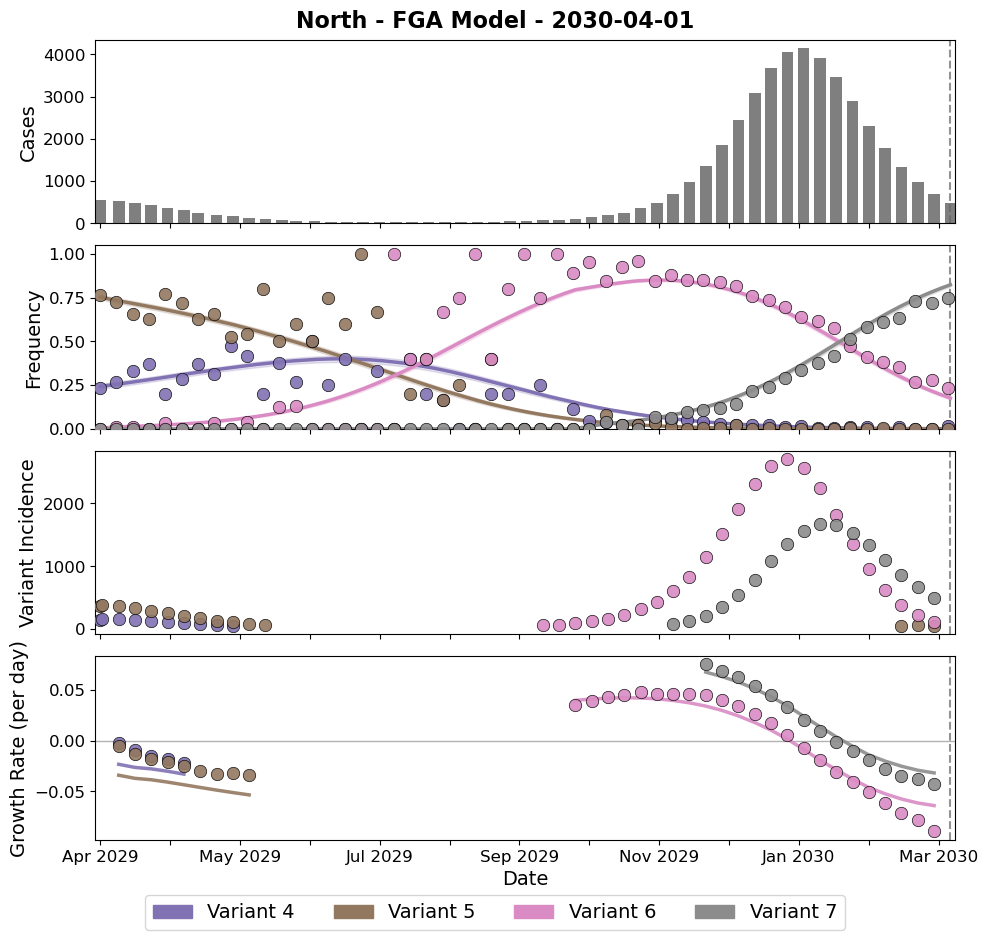

In [27]:
pivot_date="2030-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

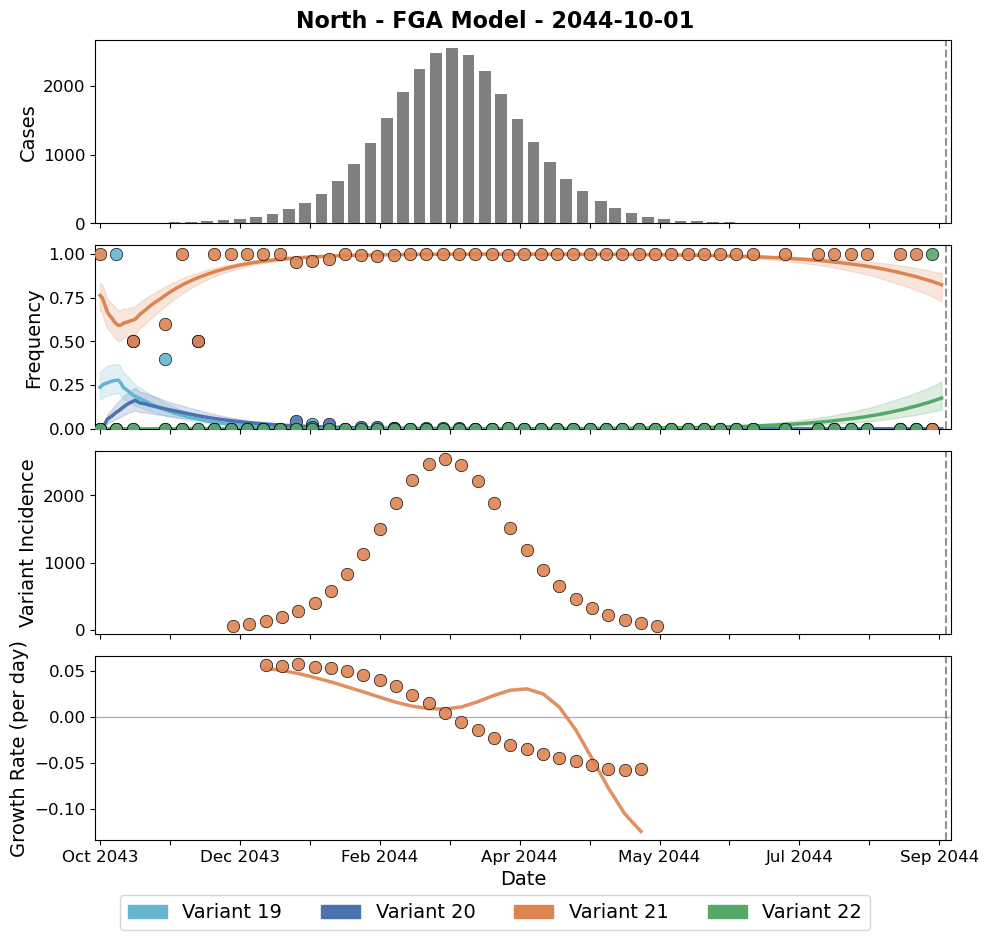

In [29]:
pivot_date="2044-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

### Tropics deme zoom-ins

In [41]:
location = "tropics"

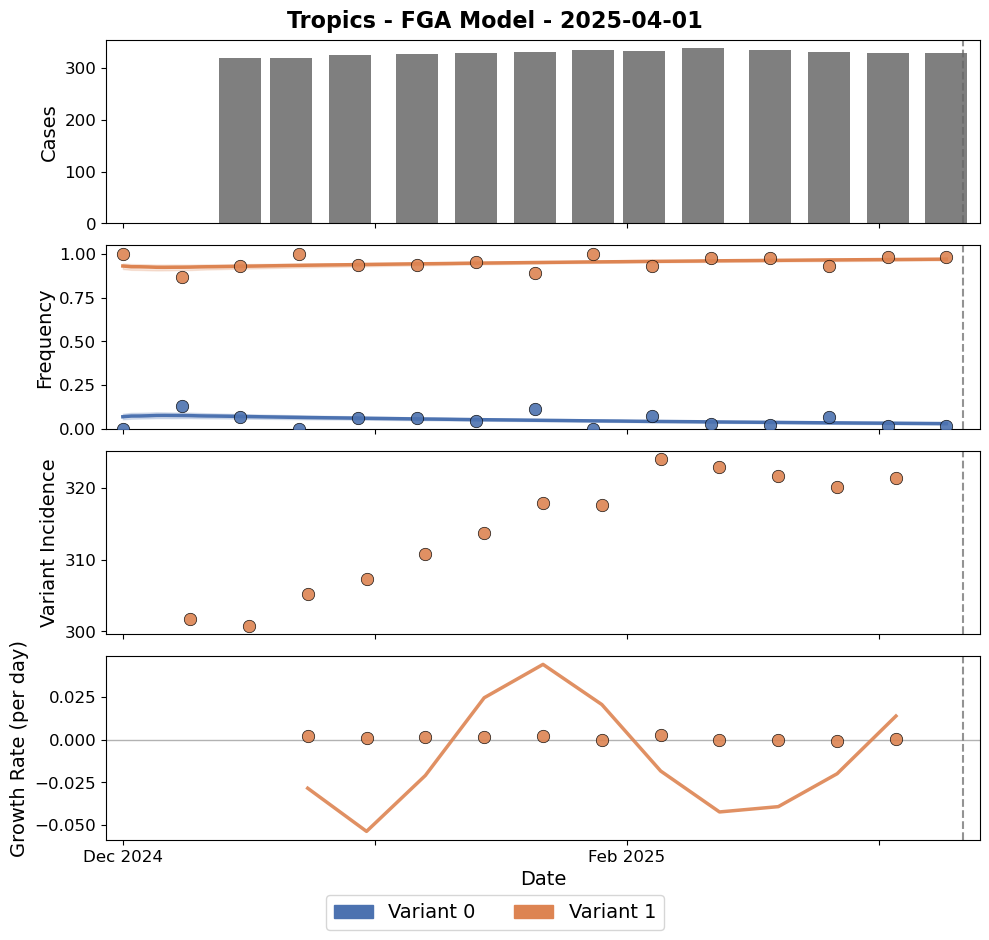

In [31]:
pivot_date="2025-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

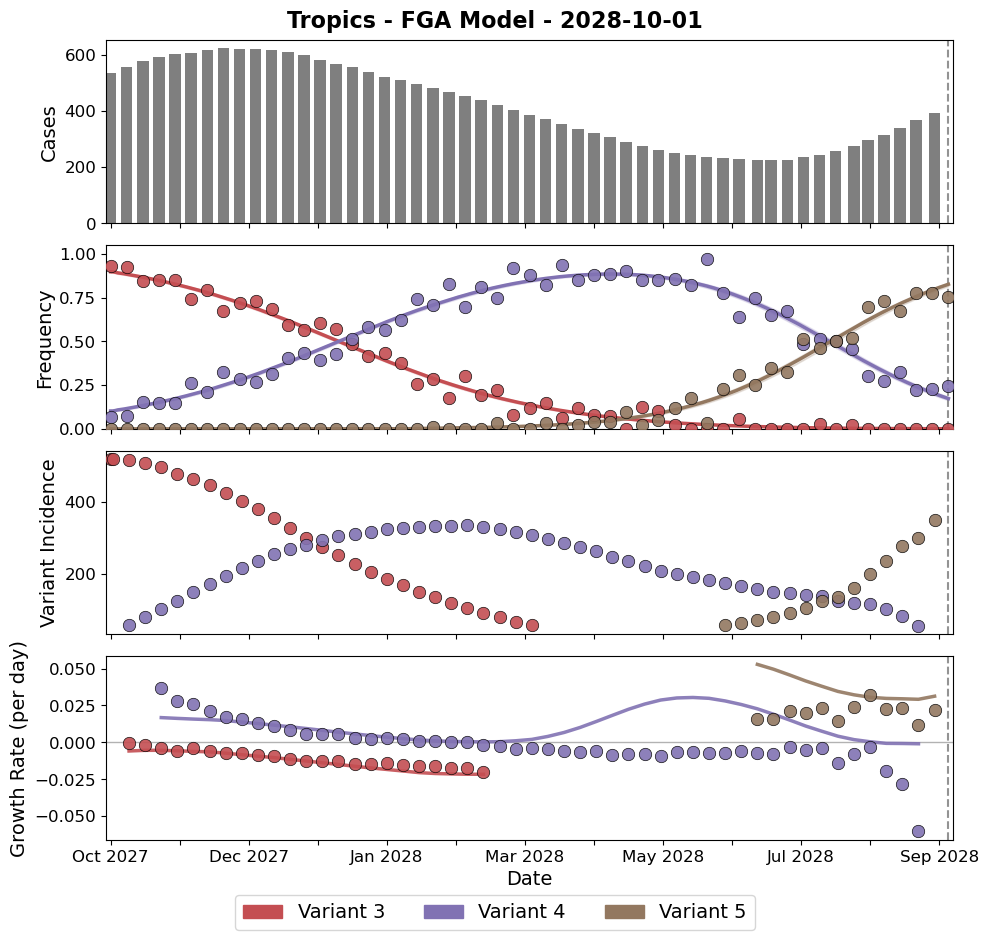

In [32]:
pivot_date="2028-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

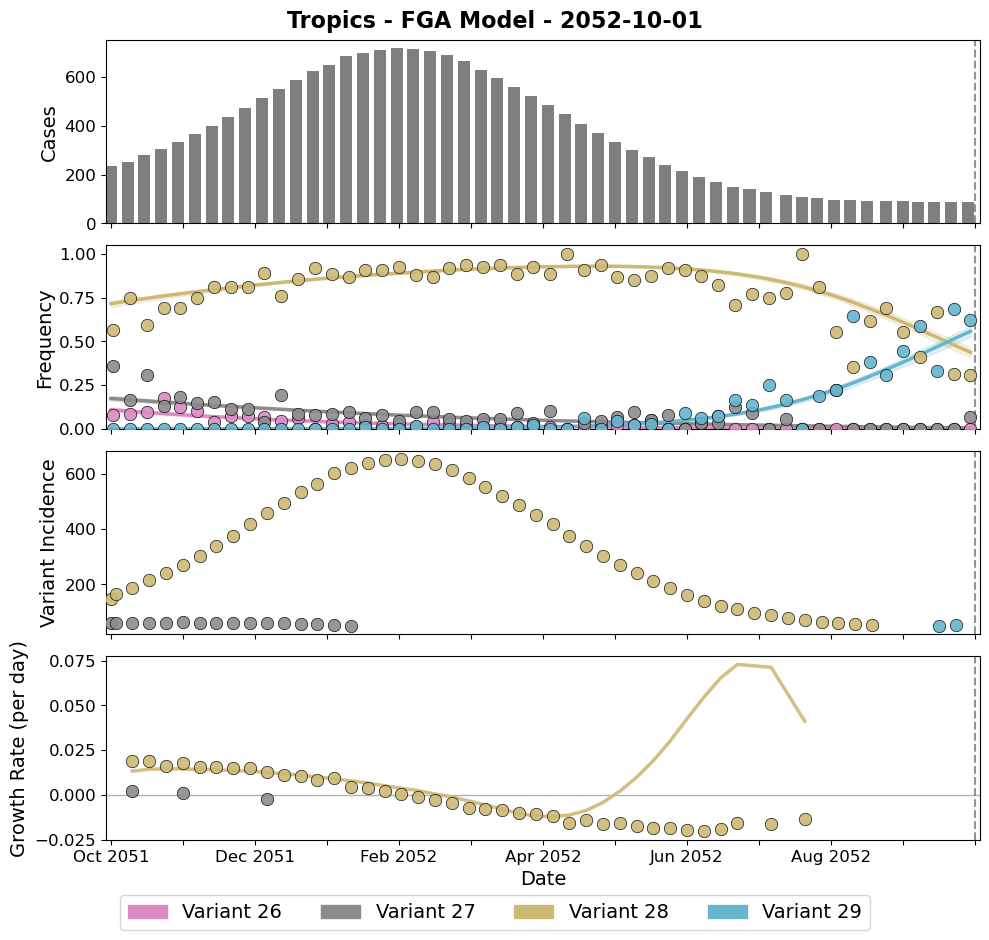

In [33]:
pivot_date="2052-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

### Southern deme zoom-ins

In [34]:
location = "south"

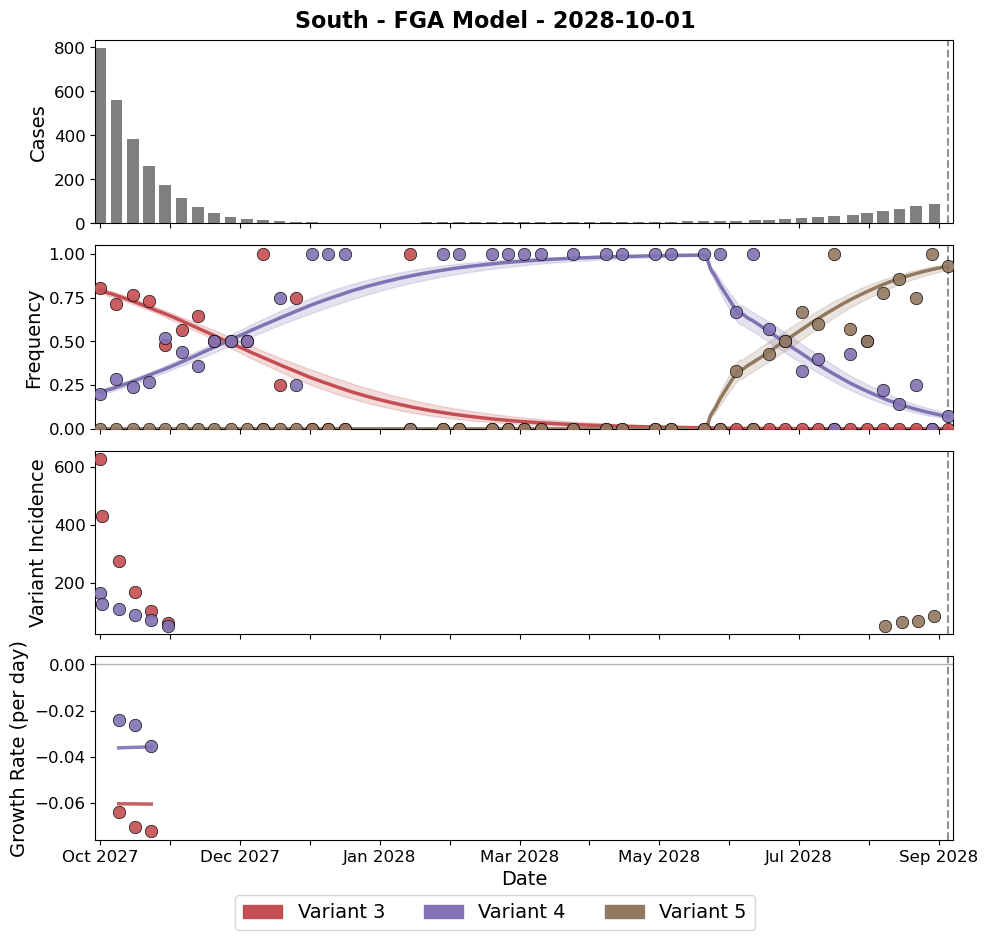

In [35]:
# Low incidence, not interesting
pivot_date="2028-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

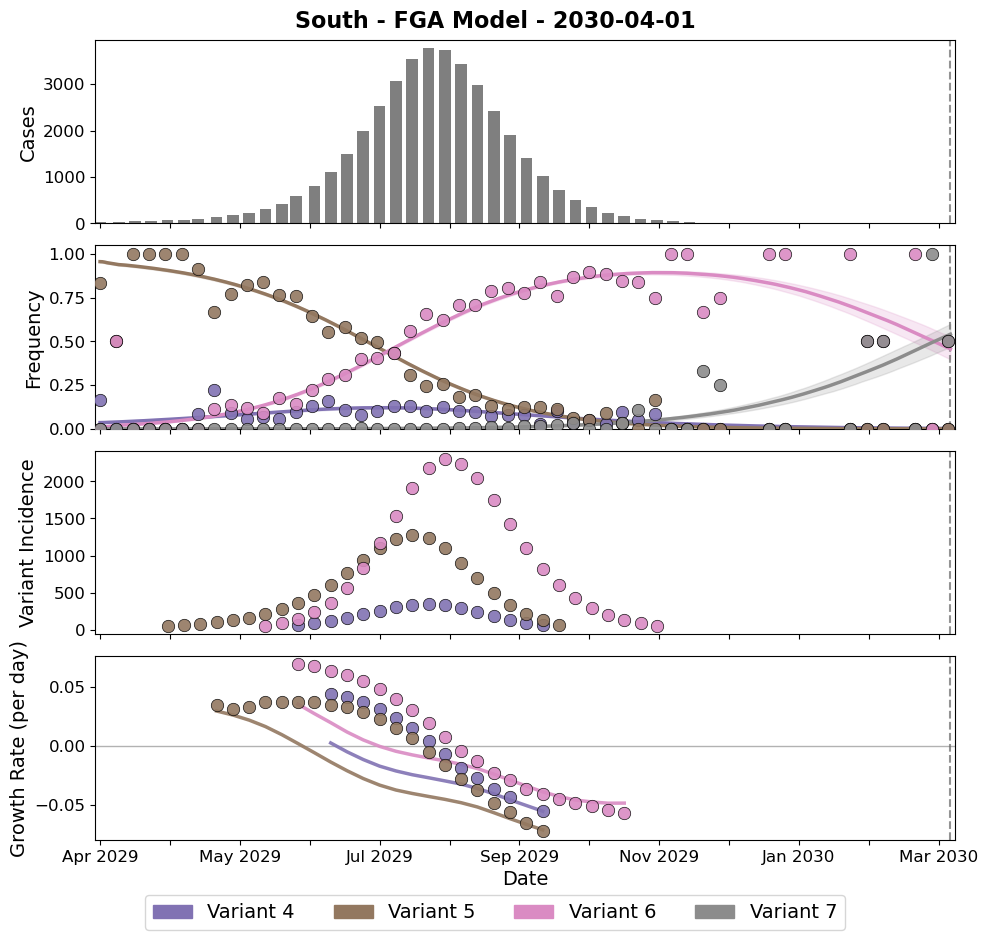

In [36]:
# Everything shifted down -- check out potential king variant with gray
pivot_date="2030-04-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

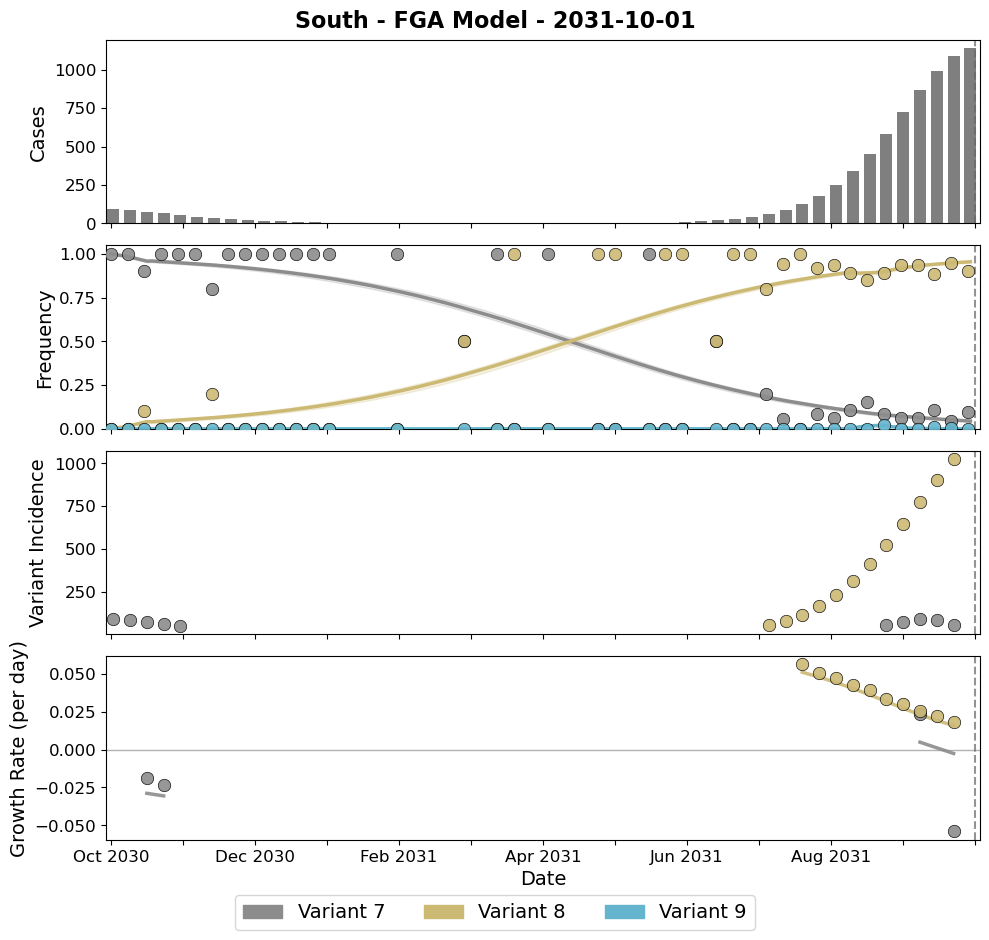

In [37]:
# Seems like low incidence -- this isn't very interesting
pivot_date="2031-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

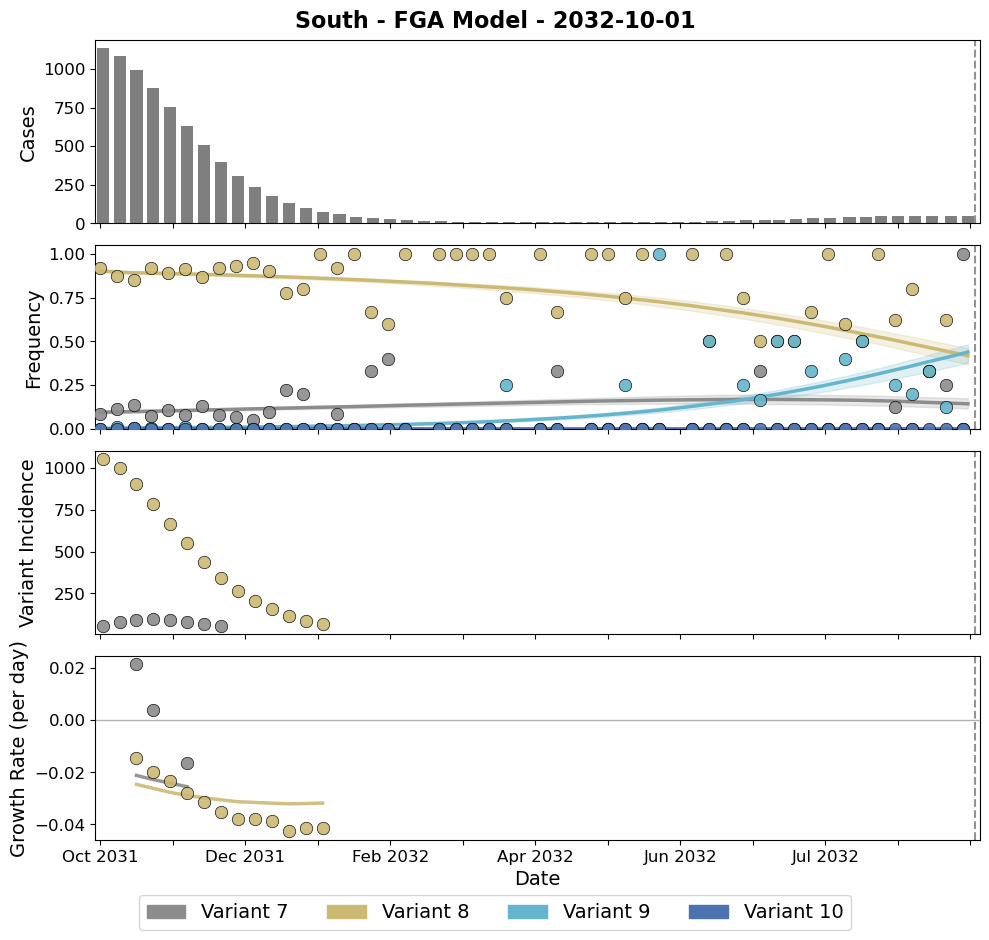

In [38]:
# Low incidence, not interesting
pivot_date="2032-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

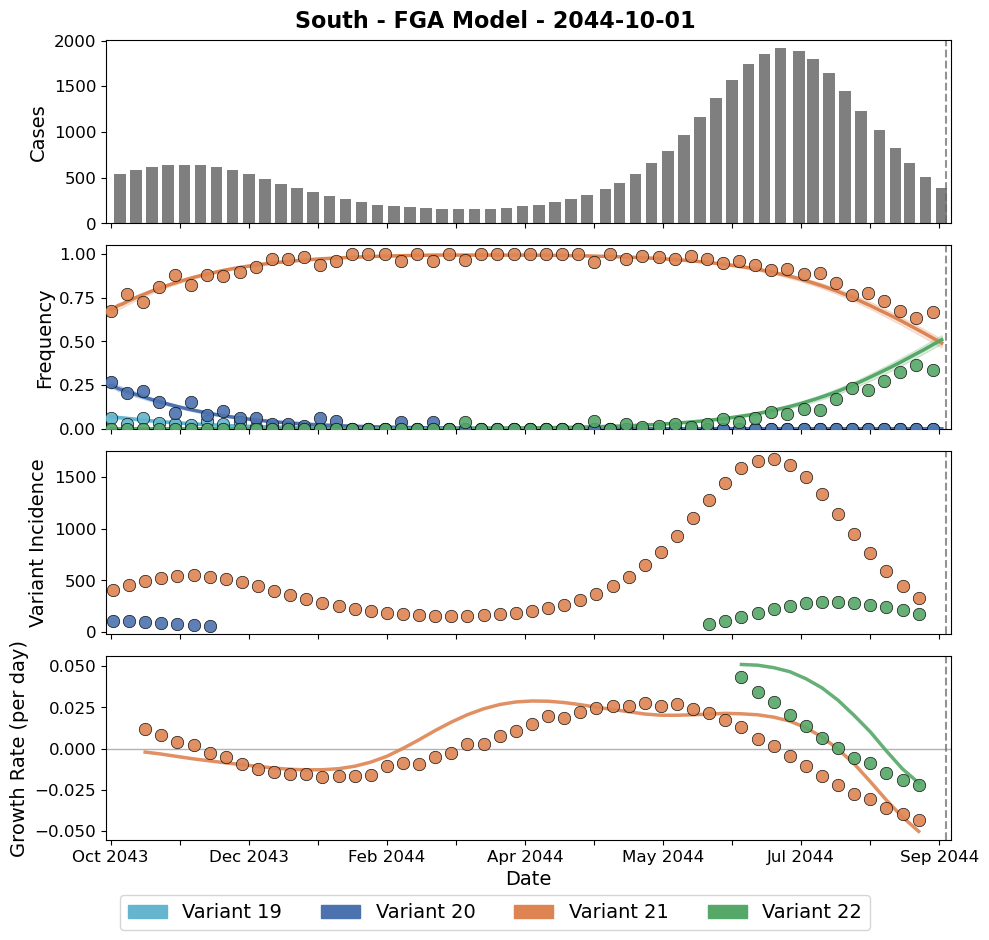

In [39]:
# Last and new variants have low incidence but do seem to impact performance of variant 21 even if it isn't in the flagged set
pivot_date="2044-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

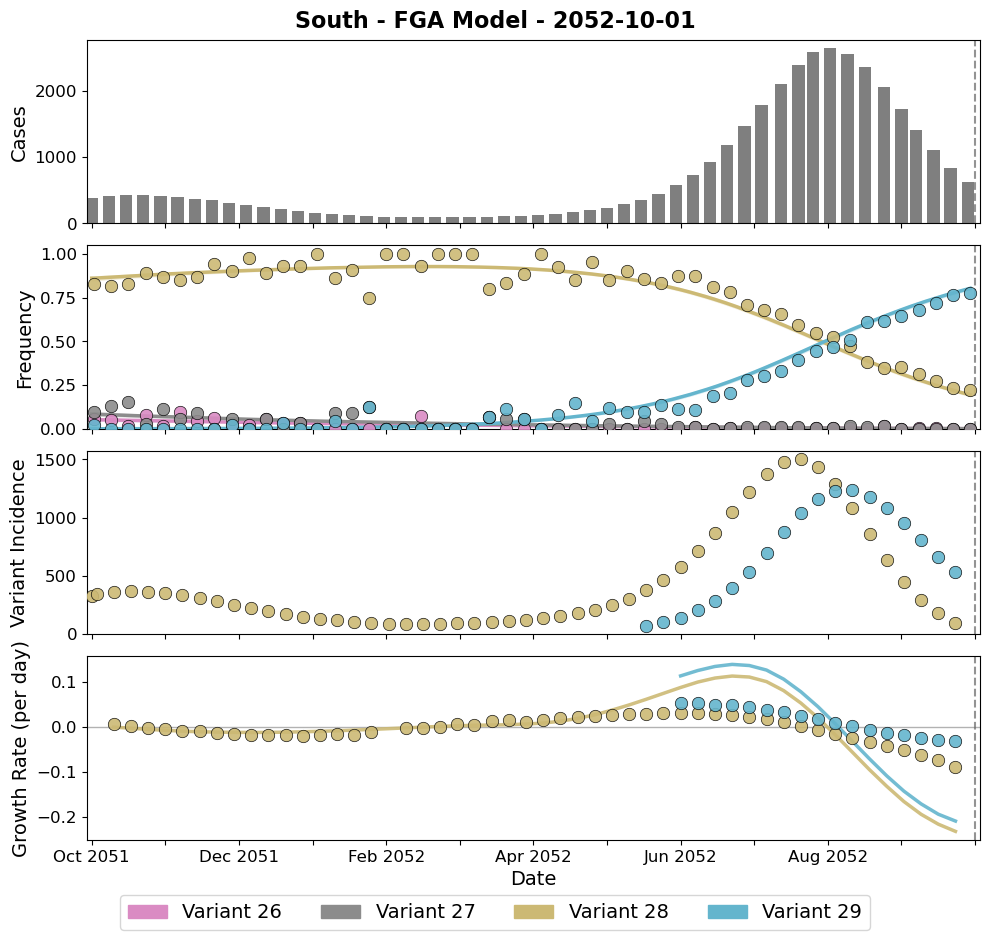

In [40]:
# Late surge seems to cause an overestimation "hump"
pivot_date="2052-10-01"
growth_rates_df = get_filtered_growth_rates_df(
build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
test_fig, _ = plot_inferred_growth_rates(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map,
    return_fig_axes=True
)

## Journal Style Comparison

The publication styling system automatically adapts your figures to meet specific journal requirements:

### Nature Style
- **Fonts**: 8pt Arial, compact sizing for space efficiency
- **Panels**: Lowercase labels (a, b, c) 
- **Dimensions**: Narrow single-column width (5.5")
- **Spines**: Clean look with top/right spines removed
- **Grid**: Very subtle (20% opacity)
- **Legend**: Frameless, 4 columns max
- **File formats**: PDF + PNG at 300 DPI

### Science Style  
- **Fonts**: 9pt Arial, slightly larger than Nature
- **Panels**: Uppercase labels (A, B, C)
- **Dimensions**: Moderate width (6.0")
- **Spines**: Clean look with top/right spines removed
- **Grid**: Subtle (20% opacity)
- **Legend**: Frameless, 5 columns max
- **File formats**: PDF + PNG at 300 DPI

### PLOS Style
- **Fonts**: 10pt Arial (required by PLOS), most readable
- **Panels**: Uppercase labels (A, B, C), positioned closer to panels
- **Dimensions**: Wider format (7.0") for better readability
- **Spines**: All spines visible but darker gray (#333)
- **Grid**: More visible (40% opacity) for easier data reading
- **Legend**: Framed with light border, 6 columns max
- **Ticks**: Longer and thicker for better visibility
- **Title**: More descriptive as preferred by PLOS
- **File formats**: High-res PNG (600 DPI) + PDF
- **Spacing**: More generous panel spacing for readability

### Key PLOS Differences

PLOS journals have specific requirements that make them stand out:

1. **Accessibility Focus**: Larger fonts, clearer grids, more visible elements
2. **Complete Borders**: Unlike Nature/Science, PLOS keeps all axis spines
3. **Descriptive Titles**: PLOS prefers more detailed figure titles
4. **Higher Resolution**: 600 DPI PNG files for online publication
5. **Framed Legends**: Professional appearance with light borders
6. **Open Access Friendly**: Optimized for online viewing and accessibility

The styling system handles all these details automatically - you just specify the journal and get compliant figures!

## Multi-Panel Growth Rate Figure Creation

Functions to create publication-ready multi-panel figures combining multiple growth rate zoom-in windows.

In [17]:
def plot_multiple_growth_rate_windows(
    window_specs: List[Dict[str, str]],
    build: str,
    color_map: Dict[str, str],
    fig_width: float = 20,
    fig_height: float = 12,
    journal_style: str = 'nature',
    title_fontsize: int = 18,
    label_fontsize: int = 14,
    tick_fontsize: int = 12,
    panel_label_size: int = 20,
    legend_fontsize: int = 16,
    show_main_title: bool = True,
    show_legend: bool = True,
    show_model_in_title: bool = True,
    variants_per_row: int = 3,
    p: int = 95
):
    """
    Create a multi-panel figure with multiple growth rate zoom-in windows.
    
    Parameters:
    -----------
    window_specs : List[Dict[str, str]]
        List of window specifications, each containing:
        - 'pivot_date': str, pivot date for analysis
        - 'location': str, location of interest
        - 'model': str, model name
    build : str
        Build name
    color_map : Dict[str, str]
        Dictionary mapping variant names to colors
    fig_width : float, default=20
        Total figure width in inches
    fig_height : float, default=12
        Total figure height in inches (increased for text legend row)
    journal_style : str, default='nature'
        Journal style for publication formatting
    title_fontsize : int, default=18
        Font size for window titles
    label_fontsize : int, default=14
        Font size for axis labels
    tick_fontsize : int, default=12
        Font size for tick labels
    panel_label_size : int, default=20
        Font size for panel labels (A, B, C, D)
    legend_fontsize : int, default=16
        Font size for variant text in legend (increased for readability)
    show_main_title : bool, default=True
        Whether to show a main title for the entire figure
    show_legend : bool, default=True
        Whether to create text-based legend row at bottom
    show_model_in_title : bool, default=True
        Whether to include model name in panel titles
    variants_per_row : int, default=3
        Maximum number of variants per row in text legend
    p : int, default=95
        Confidence level for frequency and growth rate bands (95, 80, or 50)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created matplotlib figure
    """
    n_windows = len(window_specs)
    
    # Create figure with GridSpec - add 5th row for text legend if needed
    n_rows = 5 if show_legend else 4
    fig = plt.figure(figsize=(fig_width, fig_height))
    # Increased hspace for more gap between data panels and legend
    gs = gridspec.GridSpec(n_rows, n_windows, figure=fig, hspace=0.4, wspace=0.1,
                          height_ratios=[1, 1, 1, 1, 0.5] if show_legend else [1, 1, 1, 1])
    
    # Store all axes for each window
    all_axes = []
    all_variants = set()
    window_variants = []  # Track variants per window for text legend
    
    # Create subplots for each window
    for col_idx, window_spec in enumerate(window_specs):
        pivot_date = window_spec['pivot_date']
        location = window_spec['location']
        model = window_spec['model']
        
        # Get growth rates data
        growth_rates_df = get_filtered_growth_rates_df(
            build, model, location, pivot_date, 
            spline_smoothing_factor=1.0, spline_order=3, 
            min_sequence_count=MIN_SEQUENCE_COUNT, 
            min_variant_frequency=MIN_VARIANT_FREQUENCY,
            min_variant_incidence=MIN_VARIANT_INCIDENCE
        )
        
        # Get analysis window data
        dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
        evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(
            pivot_date, build, dummy_fitness_df
        )
        
        # Get t value for pivot date
        pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")['t'].values[0]
        
        # Collect all variants for shared legend
        current_variants = set(evo_dict[location].var_names)
        all_variants.update(current_variants)
        window_variants.append(sorted(current_variants, key=lambda x: int(x) if str(x).isdigit() else float('inf')))
        
        # Create 4 subplots for this window (data panels)
        axes = []
        for row_idx in range(4):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            axes.append(ax)
        
        # Apply plotting functions
        # Panel 1: Observed cases
        plot_observed_cases_clean(
            axes[0], evo_dict, location, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 2: Frequencies with confidence intervals
        filtered_color_map = {k: v for k, v in color_map.items() if k in current_variants}
        plot_frequencies_nowcast_only(
            axes[1], evo_dict, small_freqs_df, location, model, filtered_color_map, 
            p=p, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 3: Variant incidence
        plot_variant_incidence(
            axes[2], growth_rates_df, location, filtered_color_map, evo_dict, 
            pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 4: Growth rates with confidence intervals
        plot_r_data_vs_r_model_clean(
            axes[3], growth_rates_df, location, filtered_color_map, evo_dict, 
            pivot_idx=[pivot_idx], label_fontsize=label_fontsize, p=p
        )
        
        # Remove top and right spines from all panels
        for ax in axes:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        
        # Remove y-axis labels from all except leftmost column
        if col_idx > 0:
            for ax in axes:
                ax.set_ylabel('')
        
        # Add window title at top of each column
        if show_model_in_title:
            window_title = f"{location.title()} - {model} - {pivot_date}"
        else:
            window_title = f"{location.title()} - {pivot_date}"
        axes[0].set_title(window_title, fontsize=title_fontsize, fontweight='bold', pad=20)
        
        # Format x-axis only on bottom panel
        dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
        tick_interval = 30
        max_t = pivot_idx
        tick_positions = list(range(0, max_t + 1, tick_interval))
        
        if len(tick_positions) > 1 and (max_t - tick_positions[-1]) < 15:
            pass
        elif tick_positions and tick_positions[-1] != max_t:
            tick_positions.append(max_t)
        
        # Only show x-labels on bottom row with rotation
        for i, ax in enumerate(axes):
            ax.set_xlim(-2, pivot_idx + 2)
            ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
            
            if i < 3:  # Not bottom row of data panels
                ax.set_xticklabels([])
            else:  # Bottom data panel row
                tick_labels = []
                for j, t_pos in enumerate(tick_positions):
                    if t_pos < len(dates_evofr):
                        if j % 2 == 0:
                            date_str = dates_evofr[t_pos].strftime('%b %Y')
                        else:
                            date_str = ''
                        tick_labels.append(date_str)
                    else:
                        tick_labels.append('')
                
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=tick_fontsize)
                ax.set_xlabel('')
        
        all_axes.append(axes)
    
    # Create text-based legend row if requested
    if show_legend:
        for col_idx, variants in enumerate(window_variants):
            legend_ax = fig.add_subplot(gs[4, col_idx])
            
            # Remove all axes elements
            legend_ax.set_xticks([])
            legend_ax.set_yticks([])
            for spine in legend_ax.spines.values():
                spine.set_visible(False)
            
            # Create multi-row text legend for this window's variants with left-aligned layout
            if variants:
                n_variants = len(variants)
                n_rows_legend = int(np.ceil(n_variants / variants_per_row))
                
                # Increased spacing for better readability
                x_spacing = 0.33  # Increased horizontal spacing between variants
                x_start = 0.1     # Starting x position (left margin)
                row_height = 1.0 / (n_rows_legend + 0.5)  # More vertical space with padding
                y_start = 0.95    # Start from top
                
                for i, variant in enumerate(variants):
                    # Calculate row and column position
                    row = i // variants_per_row
                    col = i % variants_per_row
                    
                    # Calculate position with fixed grid spacing
                    x_pos = x_start + col * x_spacing
                    y_pos = y_start - (row + 0.5) * row_height
                    
                    # Get color and plot text
                    color = color_map.get(variant, 'gray')
                    legend_ax.text(x_pos, y_pos, f"Variant {variant}", 
                                  transform=legend_ax.transAxes, ha='left', va='center',
                                  fontsize=legend_fontsize, color=color, fontweight='bold')
    
    # Add panel labels (A, B, C, D) for each window
    panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'][:n_windows]
    for col_idx, (axes, label) in enumerate(zip(all_axes, panel_labels)):
        # Place panel label in top-left of first subplot of each column
        ax = axes[0]
        ax.text(-0.15, 1.15, label, transform=ax.transAxes,
                fontsize=panel_label_size, fontweight='bold',
                ha='right', va='bottom')
    
    # Add main title if requested
    if show_main_title:
        fig.suptitle('Growth Rate Performance Across Locations and Models', 
                    fontsize=title_fontsize + 2, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    
    # Calculate bottom margin based on legend presence
    bottom_margin = 0.08 if show_legend else 0.04
    top_margin = 0.94 if show_main_title else 0.96
    
    plt.subplots_adjust(top=top_margin, bottom=bottom_margin)
    
    return fig

### Example Usage: Creating a 4-Panel Figure

In [6]:
save_path = '../../antigen-tex/figures/growth_rate_multi_panel_figure'

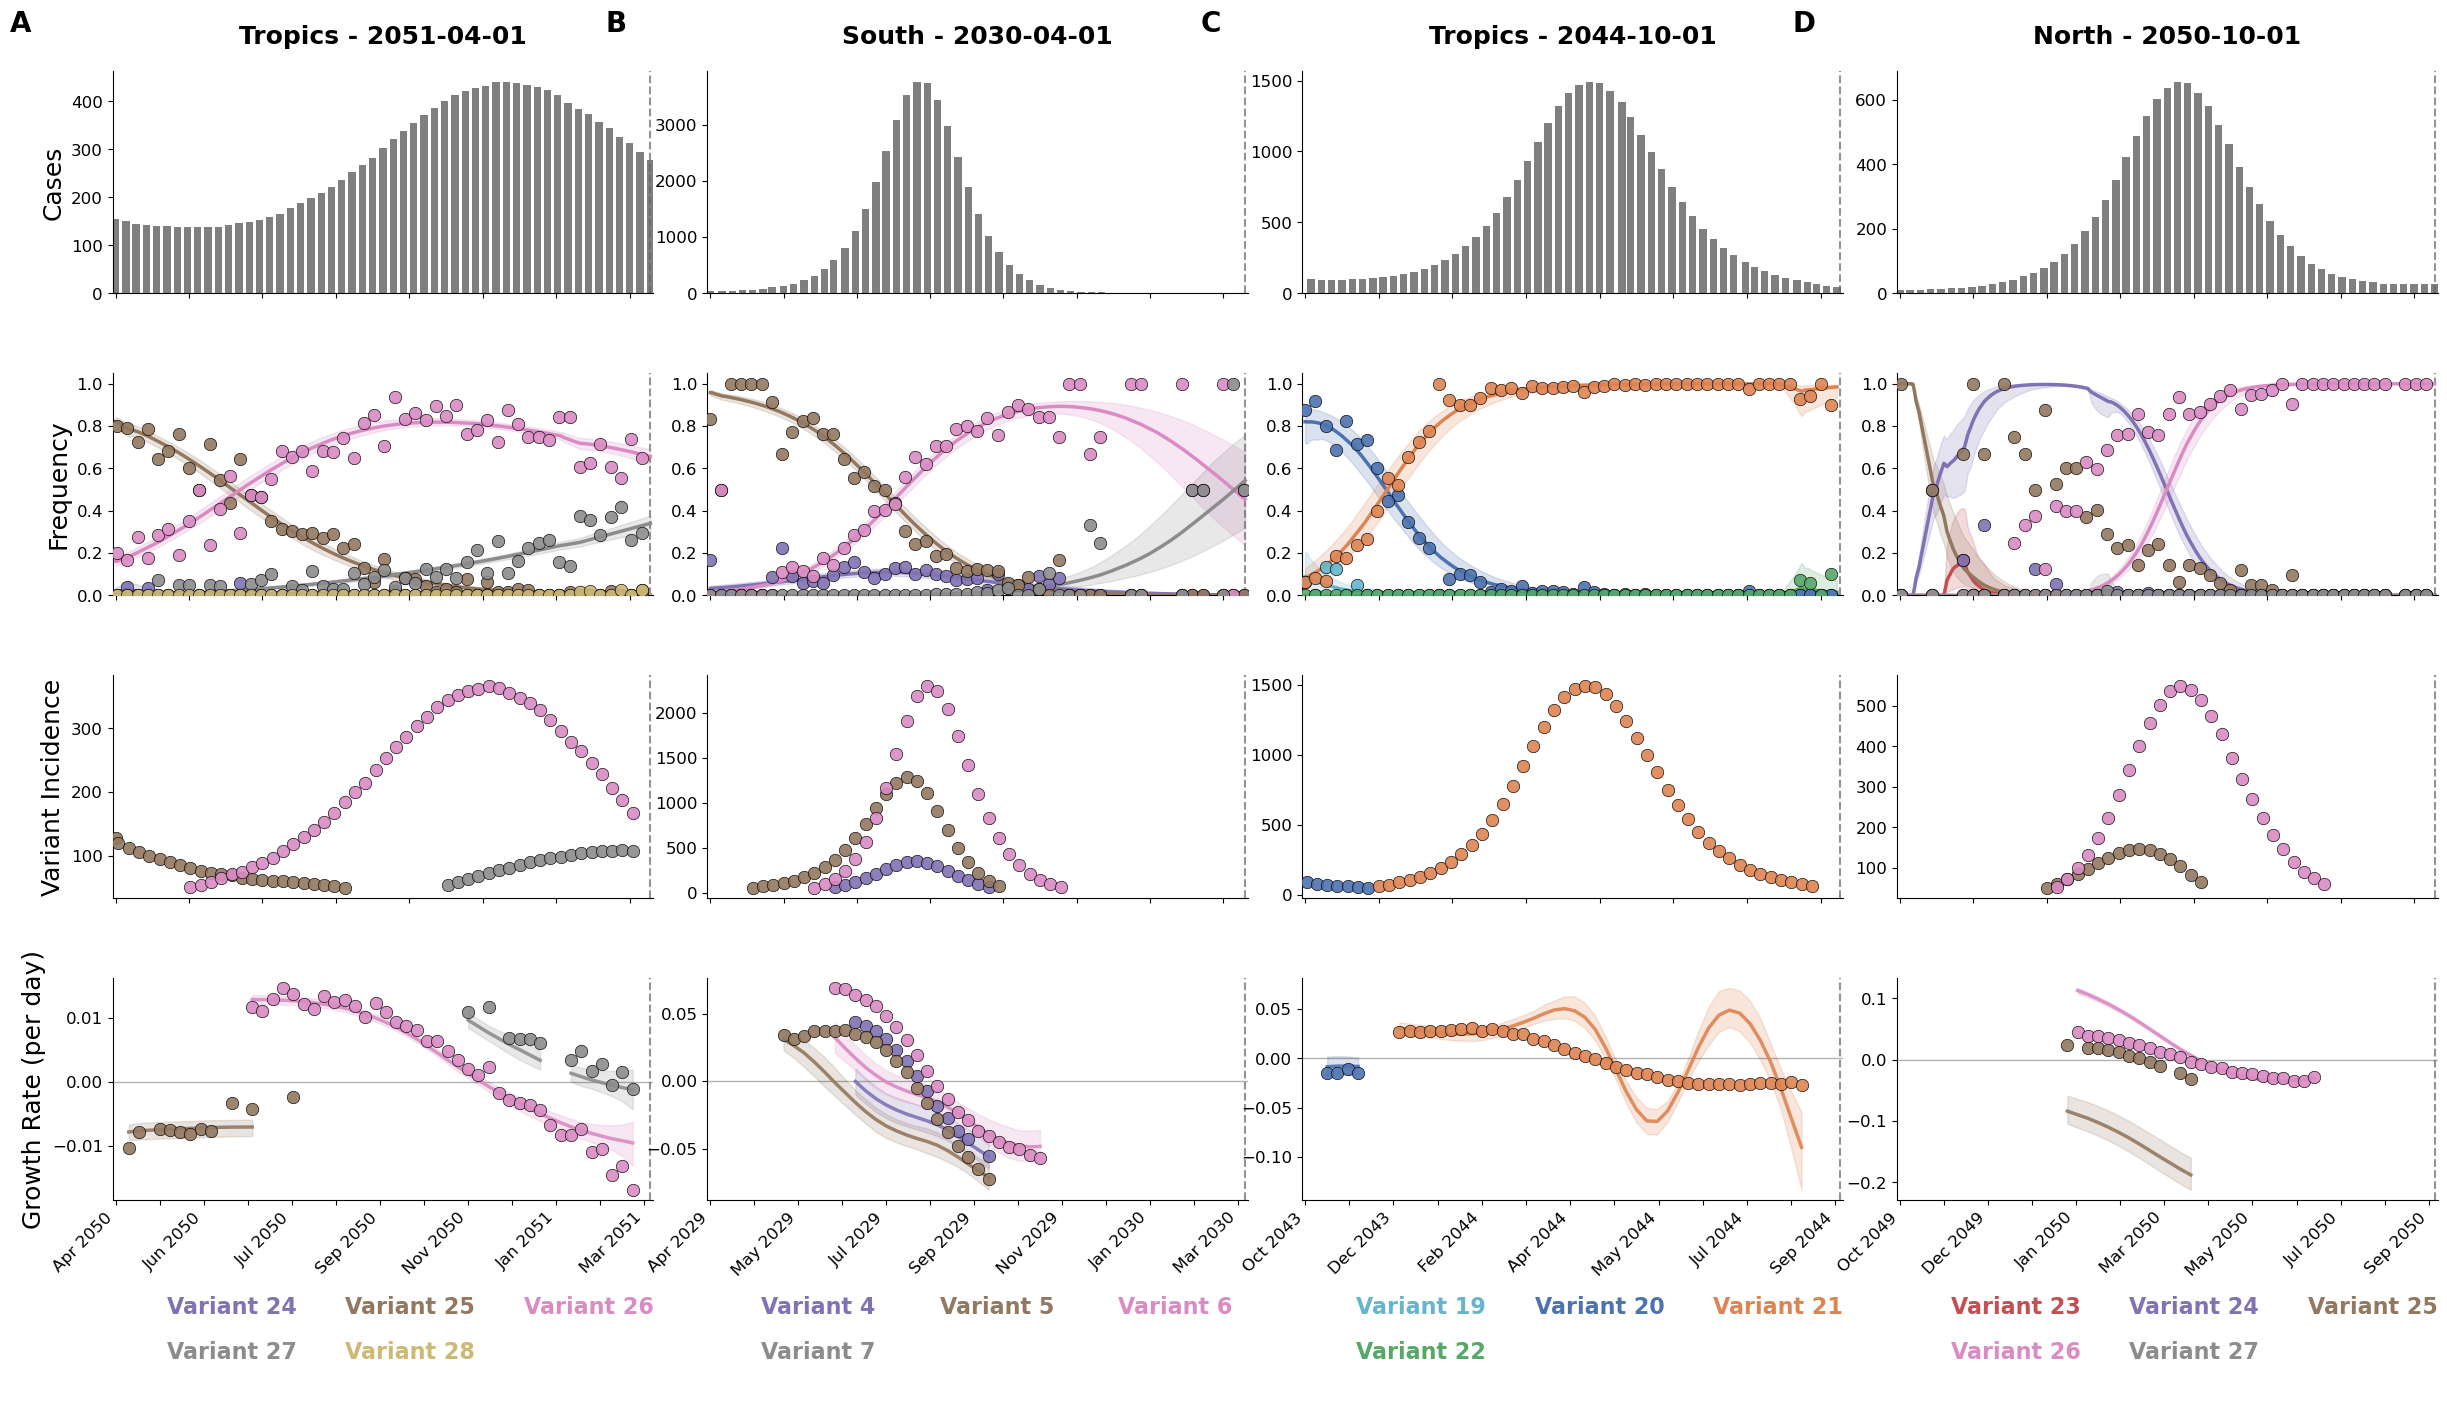

In [21]:
# Example 1: Four interesting windows showing different error patterns
window_specs_example1 = [
    {'pivot_date': '2051-04-01', 'location': 'tropics', 'model': 'GARW'},    # Good performance
    {'pivot_date': '2030-04-01', 'location': 'south', 'model': 'GARW'},  # King variant drag down
    {'pivot_date': '2044-10-01', 'location': 'tropics', 'model': 'GARW'},   # Wonky performance that we can't explain
    {'pivot_date': '2050-10-01', 'location': 'north', 'model': 'GARW'}      # Poor but confident frequency nowcasts
]

# Create the multi-panel figure
fig = plot_multiple_growth_rate_windows(
    window_specs=window_specs_example1,
    build=build,
    color_map=color_map,
    fig_width=30,
    fig_height=15,
    label_fontsize=18,
    journal_style='plos',
    show_legend=True,
    variants_per_row=3,
    show_model_in_title=False,
    show_main_title=False
)

# Save the figure 
fig.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
fig.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')

plt.show()